## GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [2]:
import os
import tensorflow as tf
import sys
import gc
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

2026-05-07 10:18:41.721917: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 10:18:41.821334: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-07 10:18:41.821459: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-07 10:18:41.835064: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-07 10:18:41.877112: I tensorflow/core/platform/cpu_feature_guar

3.10.12 (main, Jan 26 2026, 14:55:28) [GCC 11.4.0]
/bin/python3
sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-07 10:18:43.743562: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 10:18:44.006389: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 10:18:44.006451: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

sionna.phy.config.seed = 42 # Set seed for reproducible random number generation

2026-05-07 10:18:44.612735: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 10:18:44.612820: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 10:18:44.612835: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 10:18:44.879681: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-07 10:18:44.879819: I external/local_xla/xla/stream_executor

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator, BaseChannelEstimator, BaseChannelInterpolator
from sionna.phy.utils import ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank, split_dim
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder
from sionna.phy.mapping import BinarySource, Mapper, Demapper, Constellation
from sionna.phy.utils.metrics import compute_ber
from sionna.phy.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

## Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [82]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
cdl_model = "C" # CDL model to use
delay_spread = 100e-9 # s
speed = 10.0 # Speed for evaluation and training [m/s]
# Ultra-high coherence channel
# delay_spread = 10e-9  # 10 ns → Bc ≈ 16 MHz
# speed = 0.1  # 0.1 m/s → Tc ≈ 428 ms

# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 15.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz

num_prbs = 10
fft_size = 120  # 5 × 12 active subcarriers only
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = False # Null the DC subcarrier
num_guard_carriers = [0, 0] # we dont want guard bands

pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_DIM=64

############################################
## Training configuration
num_training_iterations = 30000 # Number of training iterations
batch_size = 128 # Training batch size

############################################
## Evaluation configuration
results_filename = "neural_receiver_results" # Location to save the results

In [83]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

Subcarrier spacing: 30000.0 Hz
OFDM symbol duration: 3.3333333333333335e-05 s
Pilot pattern: <sionna.phy.ofdm.pilot_pattern.KroneckerPilotPattern object at 0x7594cc3a1ab0>
Pilot spacing in time: every 14 symbols
Pilots per symbol: 240
Pilot mask shape: (1, 1, 14, 120)
Pilot mask sum per symbol: tf.Tensor([  0   0 120   0   0   0   0   0   0   0   0 120   0   0], shape=(14,), dtype=int32)


[<Figure size 640x480 with 2 Axes>]

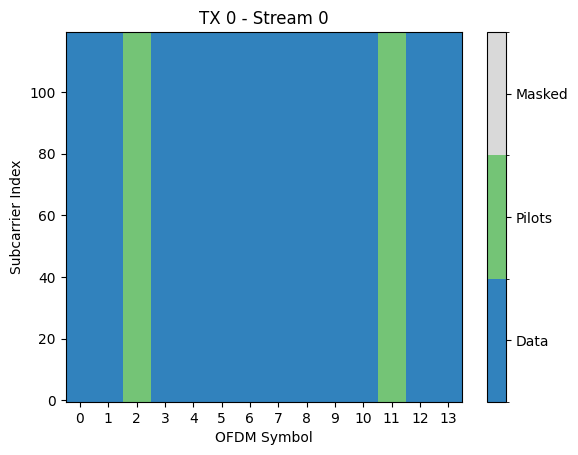

In [85]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                             pilot_pattern = pilot_pattern,
                             pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)
# resource_grid.show()
print(f"Subcarrier spacing: {resource_grid.subcarrier_spacing} Hz")
print(f"OFDM symbol duration: {resource_grid.ofdm_symbol_duration} s")
print(f"Pilot pattern: {resource_grid.pilot_pattern}")
print(f"Pilot spacing in time: every {resource_grid.pilot_pattern.num_ofdm_symbols} symbols")
print(f"Pilots per symbol: {resource_grid.pilot_pattern.num_pilot_symbols}")
print("Pilot mask shape:", resource_grid.pilot_pattern.mask.shape)
print("Pilot mask sum per symbol:", tf.reduce_sum(resource_grid.pilot_pattern.mask[0,0,:,:], axis=-1))
resource_grid.pilot_pattern.show()

In [8]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
# data symbols = 1392
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)
print(n)
print(k)

4320
2160


In [9]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

### Resource Grid Util

In [10]:
class ModifiedResourceGridMapper(Layer):
    def __init__(self, resource_grid, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots
        self._data_ind = tf.where(self._rg_type == 0)   # Indices for data
    
    def extract_pilots(self, input_rg):
        """
        Args:
            input_rg: [batch, num_streams, num_rx_ant, ofdm, fft, 2]
        Returns:
            pilot_grid: Same shape, zeros everywhere except pilot positions
        """
        input_rg = tf.squeeze(input_rg, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        
        pilot_grid = tf.zeros_like(input_rg)
        pilot_values = tf.gather_nd(input_rg, self._pilot_ind)  # [batch, num_pilots, 2]
        pilot_grid = tf.tensor_scatter_nd_update(pilot_grid, self._pilot_ind, pilot_values)
        
        pilot_grid = tf.expand_dims(pilot_grid, axis=1)  # [batch, 1, num_rx_ant, ofdm, fft, 2]
        
        return pilot_grid
    
    def extract_data(self, input_rg):
        """
        Args:
            input_rg: [batch, num_streams, num_rx_ant, ofdm, fft, 2]
        Returns:
            data_grid: Same shape, zeros everywhere except data positions
        """
        input_rg = tf.squeeze(input_rg, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        
        data_grid = tf.zeros_like(input_rg)
        data_values = tf.gather_nd(input_rg, self._data_ind)  # [batch, num_data_symbols, 2]
        data_grid = tf.tensor_scatter_nd_update(data_grid, self._data_ind, data_values)
        
        data_grid = tf.expand_dims(data_grid, axis=1)  # [batch, 1, num_rx_ant, ofdm, fft, 2]
        
        return data_grid
    
    def extract_data_symbols_only(self, input_rg):
        """
        Args:
            input_rg: [batch, num_streams, num_rx_ant, ofdm, fft, 2]
        Returns:
            data_values: [batch, 1, num_rx_ant, num_data_symbols, 2] - only data symbols
        """
        input_rg = tf.squeeze(input_rg, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        data_values = tf.gather_nd(input_rg, self._data_ind)  # [batch, num_data_symbols, 2]
        data_values = tf.expand_dims(data_values, axis=1)  # [batch, 1, num_data_symbols, 2]
        
        return data_values
    
    def replace(self, inputs):
        """
        Replace pilots in generated resource grid with pilots from real resource grid
        Args:
            inputs: [generated_y_rg, real_y_rg]
                generated_y_rg: [batch, num_streams, num_rx, ofdm, fft, 2]
                real_y_rg: [batch, num_streams, num_rx, ofdm, fft, 2]
        Returns:
            updated_y_rg: [batch, num_streams, num_rx, ofdm, fft, 2]
                          Generated data + real pilots
        """
        generated_y_rg, real_y_rg = inputs
        generated_y_rg = tf.squeeze(generated_y_rg, axis=1)  # [batch, num_rx, ofdm, fft, 2]
        real_y_rg = tf.squeeze(real_y_rg, axis=1)  # [batch, num_rx, ofdm, fft, 2]
        
        # extract pilots from real resource grid
        real_pilots = tf.gather_nd(real_y_rg, self._pilot_ind)  # [batch, num_pilots, 2]
        
        # replace pilots in generated resource grid with real pilots
        updated_y_rg = tf.tensor_scatter_nd_update(
            generated_y_rg, 
            self._pilot_ind, 
            real_pilots
        )
        updated_y_rg = tf.expand_dims(updated_y_rg, axis=1)  # [batch, 1, num_rx, ofdm, fft, 2]
        
        return updated_y_rg


# resource grid helper
rg_util = ModifiedResourceGridMapper(resource_grid)

In [11]:
@tf.function
def add_nulled_subcarriers(h_hat_active):
        """
        Add nulled subcarriers back to channel estimate.
        h_hat_active has shape (batch, 1, 1, 14, 116)
        Returns tensor with shape (batch, 1, 1, 14, 128)
        This method is integrated directly into the model to ensure proper gradient flow.
        """
        # Get dynamic batch size
        batch_size = tf.shape(h_hat_active)[0]
        
        # Split the 116 active subcarriers into two groups
        h_before_dc = h_hat_active[:, :, :, :, :59]   # First 59 (positions 5-63)
        h_after_dc = h_hat_active[:, :, :, :, 59:]    # Last 57 (positions 65-121)
        
        # Create zero tensors for guard bands and DC
        dtype = h_hat_active.dtype
        zeros_guard_low = tf.zeros([batch_size, 1, 1, 14, 5], dtype=dtype)    # Positions 0-4
        zeros_dc = tf.zeros([batch_size, 1, 1, 14, 1], dtype=dtype)           # Position 64 (DC)
        zeros_guard_high = tf.zeros([batch_size, 1, 1, 14, 6], dtype=dtype)   # Positions 122-127
        
        # Concatenate in the correct order: [0-4][5-63][64][65-121][122-127]
        h_hat_full = tf.concat([
            zeros_guard_low,    # Positions 0-4 (5 zeros)
            h_before_dc,        # Positions 5-63 (59 subcarriers) 
            zeros_dc,           # Position 64 (1 zero - DC)
            h_after_dc,         # Positions 65-121 (57 subcarriers)
            zeros_guard_high    # Positions 122-127 (6 zeros)
        ], axis=-1)
        
        return h_hat_full

### Neural Receiver <a class="anchor" id="Neural-Receiver"></a>

In [ ]:
class ResidualBlock(Layer):
    def __init__(self, name=None, **kwargs):
        super(ResidualBlock, self).__init__(name=name, **kwargs)
    
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels
        # Normalize over all 3 axes, no learnable params'
        self._layer_norm_1 = LayerNormalization(axis=[-1,-2,-3], scale=False, center=False)
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=[-1,-2,-3], scale=False, center=False)
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

In [63]:
class NeuralReceiver(Model):
    def __init__(self, **kwargs):
        super(NeuralReceiver, self).__init__(**kwargs)
        self.receiver = self.build_receiver()
    
    def build_receiver(self):
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None,
                                 name="neural_receiver_input_conv")
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None,
                                  name="neural_receiver_output_conv")

        # 2*Nt (pilots) + 2*Nr (rx data) + 2*Nr*Nt (channel est)
        # total channels = 2*Nt + 2*Nr + 2*Nr*Nt (real+imag)
        inputs = tf.keras.Input(shape=(14, None, 2*1 + 2*1 + 2*1*1))
        
        # Input conv
        z = self._input_conv(inputs)
        # Residual blocks
        z = ResidualBlock(name="neural_receiver_residual_block_1")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_2")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_3")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_4")(z)
        # Output conv
        z = self._output_conv(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_receiver")

    def call(self, inputs):
        y, x_p, h_hat = inputs # [batch, Nt, Nr, ofdm, fft, 2]
        
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0, 2, 3, 1, 4]) # [batch, ofdm, fft, Nr, 2]
        y_flat = tf.concat([y[..., 0], y[..., 1]], axis=-1)
        
        x_p = tf.squeeze(x_p, axis=2)
        x_p = tf.transpose(x_p, [0, 2, 3, 1, 4]) # [batch, ofdm, fft, Nt, 2]
        x_flat = tf.concat([x_p[..., 0], x_p[..., 1]], axis=-1)
        
        h_hat = tf.transpose(h_hat, [0, 3, 4, 1, 2, 5]) # [batch, ofdm, fft, Nt, Nr, 2]
        h_flat_I = h_hat[..., 0]  # [batch, ofdm, fft, Nt, Nr]
        h_flat_Q = h_hat[..., 1]  # [batch, ofdm, fft, Nt, Nr]
        h_flat_I = tf.reshape(h_flat_I, [tf.shape(h_hat)[0], tf.shape(h_hat)[1], tf.shape(h_hat)[2], -1])  # [batch, ofdm, fft, Nt*Nr]
        h_flat_Q = tf.reshape(h_flat_Q, [tf.shape(h_hat)[0], tf.shape(h_hat)[1], tf.shape(h_hat)[2], -1])  # [batch, ofdm, fft, Nt*Nr]
        h_flat = tf.concat([h_flat_I, h_flat_Q], axis=-1)  # [batch, ofdm, fft, 2*Nt*Nr]
        
        # z: [batch, ofdm, fft, 2*Nr+2*Nt+2*Nr*Nt]
        z = tf.concat([y_flat, x_flat, h_flat], axis=-1)
        
        z = self.receiver(z)
        
        return z

In [64]:
NR = NeuralReceiver()
NR.receiver.summary()

Model: "Neural_receiver"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_46 (InputLayer)       [(None, 14, None, 6)]     0         
                                                                 
 neural_receiver_input_conv  (None, 14, None, 128)     7040      
  (Conv2D)                                                       
                                                                 
 neural_receiver_residual_b  (None, 14, 60, 128)       725248    
 lock_1 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 60, 128)       725248    
 lock_2 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 60, 128)       725248    
 lock_3 (ResidualBlock)                            

#### Hybrid Receiver (Neural demapper)

In [101]:
class NeuralDemapper(Model):
    """Neural network for demapping"""
    def __init__(self, num_bits_per_symbol, **kwargs):
        super(NeuralDemapper, self).__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.demapper = self.build_demapper()
    
    def build_demapper(self):
        # input: [real, imag, noise]
        input_dim = 3
        inputs = tf.keras.Input(shape=(None, input_dim))
        
        z = tf.keras.layers.Dense(128, activation='relu')(inputs)
        z = tf.keras.layers.Dense(128, activation='relu')(z)
        z = tf.keras.layers.Dense(self.num_bits_per_symbol, activation=None)(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_demapper")
    
    def call(self, x_eq, no_eff):
        x_eq = tf.squeeze(x_eq, axis=[1, 2])  # [batch, num_data_symbols]
        no_eff = tf.squeeze(no_eff, axis=[1, 2])  # [batch, num_data_symbols]
        
        x_real = tf.math.real(x_eq)
        x_imag = tf.math.imag(x_eq)
        
        # Stack: [real, imag, noise]
        x_input = tf.stack([x_real, x_imag, no_eff], axis=-1)  # [batch, num_data_symbols, 3]
        
        llrs = self.demapper(x_input)  # [batch, num_data_symbols, num_bits_per_symbol]
        
        # Flatten to [batch, num_data_symbols * num_bits_per_symbol]
        llrs = tf.reshape(llrs, [tf.shape(llrs)[0], -1])
        
        return llrs


class HybridReceiver(Model):
    """LS + LMMSE Equalization + Neural Demapping"""
    def __init__(self, resource_grid, stream_manager, num_bits_per_symbol, **kwargs):
        super(HybridReceiver, self).__init__(**kwargs)
        
        self.ls_estimator = LSChannelEstimator(resource_grid, interpolation_type="nn")
        self.lmmse_equalizer = LMMSEEqualizer(resource_grid, stream_manager)
        self.neural_demapper = NeuralDemapper(num_bits_per_symbol)
    
    def call(self, inputs):
        y, no = inputs
        
        # LS channel estimation
        h_hat, err_var = self.ls_estimator(y, no)
        
        # LMMSE equalization 
        x_eq, no_eff = self.lmmse_equalizer(y, h_hat, err_var, no)
        
        # Neural demapping (single pass, no feedback)
        llrs = self.neural_demapper(x_eq, no_eff)  # [batch, n]
        
        return llrs

In [103]:
HR = HybridReceiver(
    resource_grid=resource_grid,
    stream_manager=stream_manager,
    num_bits_per_symbol=num_bits_per_symbol)
HR.neural_demapper.demapper.summary()

Model: "Neural_demapper"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, 3)]         0         
                                                                 
 dense_3 (Dense)             (None, None, 128)         512       
                                                                 
 dense_4 (Dense)             (None, None, 128)         16512     
                                                                 
 dense_5 (Dense)             (None, None, 6)           774       
                                                                 
Total params: 17798 (69.52 KB)
Trainable params: 17798 (69.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Hybrid Receiver (Neural equalizer+demapper)

In [33]:
class NeuralEqualizerDemapper(Model):
    """Neural network for joint equalization and demapping"""
    def __init__(self, num_bits_per_symbol, resource_grid, **kwargs):
        super(NeuralEqualizerDemapper, self).__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        
        # Precompute data indices from resource grid
        rg_type = resource_grid.build_type_grid()  # [1, num_rx, ofdm, subcar]
        rg_type = tf.squeeze(rg_type, axis=[0, 1])  # [ofdm, subcar]
        self._data_ind = tf.where(rg_type == 0)  # [num_data, 2]
        self.num_data_symbols = tf.shape(self._data_ind)[0]
        
        self.equalizer_demapper = self.build_equalizer_demapper()
    
    def build_equalizer_demapper(self):
        """Build neural network for joint equalization and demapping"""
        # Input: [y_real, y_imag, h_real, h_imag, err_var]
        input_dim = 5
        inputs = tf.keras.Input(shape=(None, input_dim))
        
        z = tf.keras.layers.Dense(256, activation='relu')(inputs)
        z = tf.keras.layers.Dense(256, activation='relu')(z)
        z = tf.keras.layers.Dense(128, activation='relu')(z)
        z = tf.keras.layers.Dense(self.num_bits_per_symbol, activation=None)(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="neural_equalizer_demapper")
    
    def call(self, y, h_hat, err_var):
        batch_size = tf.shape(y)[0]
        
        # Squeeze to [batch, num_rx, ofdm, subcar]
        y = tf.squeeze(y, axis=1)
        h_hat = tf.squeeze(h_hat, axis=[1,2,3])
        err_var = tf.squeeze(err_var, axis=[1,2,3])
        y = y[:, 0, :, :]  # [batch, ofdm, subcar]
        h_hat = h_hat[:, 0, :, :]
        err_var = err_var[:, 0, :, :]
        
        # Extract data positions for each batch
        def extract_data_per_batch(inputs):
            y_sample, h_sample, err_sample = inputs
            # Each: [ofdm, subcar]
            
            y_data = tf.gather_nd(y_sample, self._data_ind)  # [num_data]
            h_data = tf.gather_nd(h_sample, self._data_ind)
            err_data = tf.gather_nd(err_sample, self._data_ind)
            
            # Stack features
            y_real = tf.math.real(y_data)
            y_imag = tf.math.imag(y_data)
            h_real = tf.math.real(h_data)
            h_imag = tf.math.imag(h_data)
            
            features = tf.stack([y_real, y_imag, h_real, h_imag, err_data], axis=-1)
            return features  # [num_data, 5]
        
        x_input = tf.map_fn(
            extract_data_per_batch,
            (y, h_hat, err_var),
            fn_output_signature=tf.TensorSpec(shape=(None, 5), dtype=tf.float32)
        )  # [batch, num_data, 5]
        
        # Pass through neural network
        llrs = self.equalizer_demapper(x_input)  # [batch, num_data, num_bits_per_symbol]
        
        # Flatten to [batch, num_data * num_bits_per_symbol]
        llrs = tf.reshape(llrs, [batch_size, -1])
        
        return llrs


class HybridReceiver(Model):
    """LS Channel Estimation + Neural Equalization and Demapping"""
    def __init__(self, resource_grid, stream_manager, num_bits_per_symbol, **kwargs):
        super(HybridReceiver, self).__init__(**kwargs)
        
        self.ls_estimator = LSChannelEstimator(resource_grid, interpolation_type="nn")
        self.neural_equalizer_demapper = NeuralEqualizerDemapper(
            num_bits_per_symbol, 
            resource_grid
        )
        self.resource_grid = resource_grid
        self.stream_manager = stream_manager
    
    def call(self, inputs):
        y, no = inputs
        
        # LS channel estimation
        h_hat, err_var = self.ls_estimator([y, no])
        
        # Neural equalization and demapping
        llrs = self.neural_equalizer_demapper(y, h_hat, err_var)
        
        return llrs

In [34]:
HR = HybridReceiver(
    resource_grid=resource_grid,
    stream_manager=stream_manager,
    num_bits_per_symbol=num_bits_per_symbol)
HR.neural_equalizer_demapper.equalizer_demapper.summary()

Model: "neural_equalizer_demapper"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, None, 5)]         0         
                                                                 
 dense_3 (Dense)             (None, None, 256)         1536      
                                                                 
 dense_4 (Dense)             (None, None, 256)         65792     
                                                                 
 dense_5 (Dense)             (None, None, 128)         32896     
                                                                 
 dense_6 (Dense)             (None, None, 6)           774       
                                                                 
Total params: 100998 (394.52 KB)
Trainable params: 100998 (394.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Conv2D GAN

In [15]:
class GANGenerator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANGenerator, self).__init__(**kwargs)
        self.generator = self.build_generator()

    def build_generator(self):
        """Builds the generator model."""
        x_real_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2)
        noise_input = tf.keras.layers.Input(shape=(14,128,noise_dim)) 
        c_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2) or (batch,14,128,4) for pilots
        
        x = tf.keras.layers.Concatenate()([x_real_input, noise_input, c_input])

        x = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        
        skip_processed = tf.keras.layers.Conv2D(256, (1,1), padding='same')(x_real_input)
        x = tf.keras.layers.Add()([x, skip_processed])

        x = tf.keras.layers.Conv2D(filters=2, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        
        return  tf.keras.Model(inputs=[x_real_input, noise_input, c_input], outputs=x, name="GANChannel_Generator")
    
    def call(self, z, x, extra_condition):
        # [batch,Nt,Nr,,14,128,2]
        x = tf.squeeze(x, axis=1) # [batch,Nr,14,128,2]
        x = tf.transpose(x, [0,2,3,1,4]) # [batch,14,128,Nr,2]
        x_flat = tf.concat([x[..., 0], x[..., 1]], axis=-1) # [batch,14,128,2*Nr]

        c = tf.squeeze(extra_condition, axis=1) # [batch,Nr,14,128,2]
        c = tf.transpose(c, [0,2,3,1,4]) # [batch,14,128,Nr,2]
        c_flat = tf.concat([c[..., 0], c[..., 1]], axis=-1) # [batch,14,128,2*Nr]
        
        y = self.generator([x_flat, z, c_flat]) # [batch,14,128,2*Nr]
        
        y = tf.expand_dims(y, axis=1)
        y = tf.expand_dims(y, axis=2) # [batch,Nt,Nr,14,128,2]
        
        return y


In [16]:
gan_generator = GANGenerator()
gan_generator.generator.summary()

Model: "GANChannel_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 14, 128, 100)]       0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 14, 128, 104)         0         ['input_2[0][0]',             
                                                                     'input_3[0

In [17]:
class GANDiscriminator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANDiscriminator, self).__init__(**kwargs)
        self.discriminator = self.build_discriminator()
    
    def build_discriminator(self):
        """Builds the discriminator model."""
        y_rg = tf.keras.layers.Input(shape=(14,128,6)) # 14,128,6 or 14,128,8 for pilots

        y = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same')(y_rg)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)

        # y = tf.keras.layers.Flatten()(y)
        # # FC = tf.nn.relu(tf.keras.layers.Dense(100, activation=None)(FC))
        # D_logit = tf.keras.layers.Dense(1, activation='linear')(y) # sigmoid
        # # D_prob = tf.nn.sigmoid(conv4)
        
        y = tf.keras.layers.GlobalAveragePooling2D()(y)
        y = tf.keras.layers.Dense(128)(y)
        D_logit = tf.keras.layers.Dense(1, activation='linear')(y)
        
        return tf.keras.Model(inputs=y_rg, outputs=D_logit, name="GANChannel_Discriminator")
    
    def call(self, y, x, extra_condition):
        # [batch,Nt,Nr,14,128,2]
        y = tf.squeeze(y, axis=1) # [batch,Nr,14,128,2]
        y = tf.transpose(y, [0,2,3,1,4]) # [batch,14,128,Nr,2]
        y_flat = tf.concat([y[..., 0], y[..., 1]], axis=-1) # [batch,14,128,2*Nr]

        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1,4])
        x_flat = tf.concat([x[..., 0], x[..., 1]], axis=-1) # [batch,14,128,2*Nr]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1,4])
        c_flat = tf.concat([c[..., 0], c[..., 1]], axis=-1) # [batch,14,128,2*Nr]

        cat = tf.concat([y_flat, x_flat, c_flat], axis=-1) # [batch,14,128,c]

        y_logit = self.discriminator(cat)
        
        return y_logit


In [18]:
gan_discriminator = GANDiscriminator()
gan_discriminator.discriminator.summary()

Model: "GANChannel_Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 14, 128, 6)]      0         
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 128, 64)       3520      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 128, 64)       0         
                                                                 
 conv2d_14 (Conv2D)          (None, 14, 128, 128)      73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 14, 128, 128)      0         
                                                                 
 conv2d_15 (Conv2D)          (None, 14, 128, 256)      295168    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 12

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

### Wrapper

In [19]:
class ConstellationGenerator(Layer):
    """generate trained constellation directly"""
    def __init__(self, num_bits_per_symbol, 
                 num_ofdm_symbols=14, 
                 fft_size=128,
                 filters=[64, 128, 256],
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.num_constellation_points = 2 ** num_bits_per_symbol
        self.num_ofdm_symbols = num_ofdm_symbols
        self.fft_size = fft_size
        self.filters = filters
        
        # Conv2D feature extraction (same as GAN structure)
        self.conv_layers = []
        for num_filters in filters:
            self.conv_layers.append(tf.keras.layers.Conv2D(
                filters=num_filters, 
                kernel_size=(3, 3), 
                padding='same', 
                use_bias=False
            ))
            self.conv_layers.append(tf.keras.layers.ReLU())
        
        self.skip_conv = tf.keras.layers.Conv2D(filters[-1], (1, 1), padding='same')
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()
        
        self.dense1 = Dense(256)
        self.relu = tf.keras.layers.ReLU()
        
        # constellation I/Q output
        self.constellation_I_output = Dense(self.num_constellation_points)
        self.constellation_Q_output = Dense(self.num_constellation_points)
        
    def build(self, input_shape):
        # QAM weight initialization
        qam_constellation = Constellation("qam", self.num_bits_per_symbol)
        qam_points = qam_constellation.points
        initial_I = tf.math.real(qam_points)
        initial_Q = tf.math.imag(qam_points)
        
        self.qam_I_init = initial_I
        self.qam_Q_init = initial_Q
        
        super().build(input_shape)
    
    def call(self, resource_grid, training=False):
        """
        Args:
            resource_grid: [batch, num_ofdm_symbols, fft_size, num_streams_per_tx]
        Returns:
            points_I: [batch, M] - constellation I values
            points_Q: [batch, M] - constellation Q values
        """
        rg_real = tf.math.real(resource_grid)
        rg_imag = tf.math.imag(resource_grid)
        rg_input = tf.concat([rg_real, rg_imag], axis=-1)
        
        # Conv2D feature extraction
        rg_skip = rg_input
        x = rg_input
        for layer in self.conv_layers:
            x = layer(x, training=training)
        # skip connection
        skip_processed = self.skip_conv(rg_skip, training=training)
        x = tf.keras.layers.Add()([x, skip_processed])
        # Global pooling
        x = self.global_pool(x)  # [batch, 256]
        # output Dense layers
        x = self.dense1(x, training=training)
        x = self.relu(x)
        
        # directly output constellation points
        points_I = self.constellation_I_output(x, training=training)  # [batch, M]
        points_Q = self.constellation_Q_output(x, training=training)  # [batch, M]
        
        # per-symbol normalization
        point_energy = points_I**2 + points_Q**2  # [batch, M]
        avg_energy = tf.reduce_mean(point_energy, axis=-1, keepdims=True)  # [batch, 1]
        normalization_factor = tf.sqrt(avg_energy)
        points_I = points_I / normalization_factor
        points_Q = points_Q / normalization_factor
        
        return points_I, points_Q

class BatchedConstellation:
    """
    batched constellation points as resource grid (frame) vary per batch sample, 
    sionna mapper takes a single constellation.
    frame -> unique constellation (bits map to these) <- update by loss
    """
    def __init__(self, num_bits_per_symbol):
        self.num_bits_per_symbol = num_bits_per_symbol
        self._points = None  # set dynamically
    
    def set_points(self, points):
        """Set the constellation points for current batch"""
        self._points = points  # [batch, 2^num_bits_per_symbol]
    
    def __call__(self):
        return self._points
    
    @property
    def points(self):
        return self._points


class ConditionalMapper(Layer):
    """
    map each sample in batch separately.
    """
    def __init__(self, num_bits_per_symbol, 
                 num_ofdm_symbols=14,
                 fft_size=128,
                 filters=[64, 128, 256],
                 return_indices=False, 
                 **kwargs):
        super().__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.return_indices = return_indices
        
        # Constellation generator
        self.constellation_generator = ConstellationGenerator(
            num_bits_per_symbol,
            num_ofdm_symbols=num_ofdm_symbols,
            fft_size=fft_size,
            filters=filters
        )
        
        # Pre-compute bit positions for mapping
        n = num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)
    
    def _map_bits_to_symbols(self, bits, points_I, points_Q):
        """
        Map bits to symbols using constellation points.
        Similar to Sionna Mapper but handles batched constellations.
        Args:
            bits: [batch, num_bits] - binary values
            constellation_points: [batch, 2^num_bits_per_symbol] - complex constellation
        Returns:
            x_real: [batch, num_symbols, 2] where last dim is [I, Q]
            indices: [batch, num_symbols] - symbol indices
        """
        # Convert to int32
        bits = tf.cast(bits, dtype=tf.int32)
        
        # [batch, num_bits] -> [batch, num_symbols, num_bits_per_symbol]
        batch_size = tf.shape(bits)[0]
        num_bits = tf.shape(bits)[1]
        num_symbols = num_bits // self.num_bits_per_symbol
        
        bits_reshaped = tf.reshape(bits, [batch_size, num_symbols, self.num_bits_per_symbol])
        
        # Convert bits to integer indices
        shifted_bits = tf.bitwise.left_shift(bits_reshaped, self._bit_positions)
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)  # [batch, num_symbols]
        
        # Map to constellation - need to handle batch dimension
        # Gather I and Q separately using batch_dims
        x_I = tf.gather(points_I, int_rep, batch_dims=1, axis=1)  # [batch, num_symbols]
        x_Q = tf.gather(points_Q, int_rep, batch_dims=1, axis=1)  # [batch, num_symbols]
         
        x_real = tf.stack([x_I, x_Q], axis=-1) # [batch, num_symbols, 2]
        
        if self.return_indices:
            return x_real, int_rep
        else:
            return x_real
    
    def call(self, inputs, training=False):
        """
        Args:
            inputs: tuple of (bits, resource_grid)
                bits: [batch, num_bits] 
                resource_grid: [batch, num_ofdm_symbols, fft_size, num_streams_per_tx]
        Returns:
            symbols: [batch, num_symbols] - complex symbols
            constellation_points: [batch, 2^num_bits_per_symbol] - for visualization
            indices: [batch, num_symbols] - if return_indices=True
        """
        bits, resource_grid = inputs
        
        # Generate conditioned constellation for each sample in batch
        points_I, points_Q = self.constellation_generator(
            resource_grid, training=training
        )  # [batch, M]
        
        # Map bits to symbols
        result = self._map_bits_to_symbols(bits, points_I, points_Q)
        
        constellation_points = tf.complex(points_I, points_Q) # for learned constellation check only

        if self.return_indices:
            symbols, indices = result
            return symbols, constellation_points, indices
        else:
            symbols = result
            return symbols, constellation_points

In [20]:
class OFDMChannelReal(Layer):
    def __init__(self, channel_model, resource_grid, 
                 normalize_channel=False, return_channel=False, **kwargs):
        super().__init__(**kwargs)
        
        self._cir_sampler = channel_model
        self._rg = resource_grid
        self._normalize_channel = normalize_channel
        self._return_channel = return_channel
        
        self._generate_channel = GenerateOFDMChannel(
            self._cir_sampler, self._rg, self._normalize_channel
        )
    
    def call(self, x_real, no=None):
        """
        Args:
            x_real: [batch, 1, 1, 14, 128, 2] where last dim is [I, Q]
            no: noise variance (real)
        Returns:
            y_real: [batch, 1, 1, 14, 128, 2] real received signal
            h_real: [batch, 1, 1, 1, 1, 14, 128, 2] real channel (optional)
        """
        batch_size = tf.shape(x_real)[0]
        # Complex channel from Sionna
        h_freq_complex = self._generate_channel(batch_size)  # [batch, 1, 1, num_rx, num_tx, ofdm_syms, subcarriers]
        
        # Convert channel to real representation
        h_real_part = tf.math.real(h_freq_complex)  # [batch, 1, 1, 1, 1, 14, 128]
        h_imag_part = tf.math.imag(h_freq_complex)
        
        # Split x_real into I and Q
        x_I = x_real[..., 0]  # [batch, 1, 1, 14, 128]
        x_Q = x_real[..., 1]  # [batch, 1, 1, 14, 128]
        
        # Squeeze channel dimensions for broadcasting
        h_real = tf.squeeze(h_real_part, axis=[3, 4])  # [batch, 1, 1, 14, 128]
        h_imag = tf.squeeze(h_imag_part, axis=[3, 4])
        
        # Apply complex multiplication as real: (a+bi)(c+di) = (ac-bd) + (ad+bc)i
        y_I = h_real * x_I - h_imag * x_Q
        y_Q = h_imag * x_I + h_real * x_Q
        
        # Add noise
        if no is not None:
            # AWGN: split noise power equally between I and Q
            no = tf.reshape(no, [-1, 1, 1, 1, 1])
            noise_I = tf.random.normal(tf.shape(y_I), stddev=tf.sqrt(no/2))
            noise_Q = tf.random.normal(tf.shape(y_Q), stddev=tf.sqrt(no/2))
            y_I = y_I + noise_I
            y_Q = y_Q + noise_Q
        
        # Stack I and Q in last dimension
        y_real = tf.stack([y_I, y_Q], axis=-1)  # [batch, 1, 1, 14, 128, 2]
        
        if self._return_channel:
            # Stack channel I and Q
            h_real_out = tf.stack([h_real, h_imag], axis=-1)  # [batch, 1, 1, 14, 128, 2]
            h_real_out = tf.expand_dims(h_real_out, axis=3)  # [batch, 1, 1, 1, 1, 14, 128, 2]
            h_real_out = tf.expand_dims(h_real_out, axis=4)  # [batch, 1, 1, 1, 1, 14, 128, 2]
            
            return y_real, h_real_out
        else:
            return y_real

class MapperReal(sionna.phy.Block): 
    def __init__(self,
                 constellation_type=None,
                 num_bits_per_symbol=None,
                 constellation=None,
                 return_indices=False,
                 precision=None,
                 **kwargs
                ):
        super().__init__(precision=precision, **kwargs)
        self._constellation = Constellation.check_or_create(
                                constellation_type=constellation_type,
                                num_bits_per_symbol=num_bits_per_symbol,
                                constellation=constellation,
                                precision=precision)
        self._return_indices = return_indices
        n = self.constellation.num_bits_per_symbol
        self._bit_positions = tf.cast(tf.range(n-1, -1, -1), dtype=tf.int32)

    @property
    def constellation(self):
        return self._constellation
    
    def call(self, bits):
        """
        Args:
            bits: [..., num_bits] binary tensor
        Returns:
            x_real: [..., num_symbols, 2] where last dim is [I, Q]
        """
        bits = tf.cast(bits, dtype=tf.int32)

        # Reshape last dimensions to the desired format
        n1 = int(bits.shape[-1]/self.constellation.num_bits_per_symbol)
        new_shape = [n1 , self.constellation.num_bits_per_symbol]
        bits = split_dim(bits, new_shape, axis=tf.rank(bits)-1)

        # Use bitwise left shift to compute powers of two
        shifted_bits = tf.bitwise.left_shift(bits, self._bit_positions)
        # Compute the integer representation using bitwise operations
        int_rep = tf.reduce_sum(shifted_bits, axis=-1)
        
        # Lookup I and Q from trainable constellation
        x_I = tf.gather(tf.math.real(self._constellation()), int_rep, axis=0)
        x_Q = tf.gather(tf.math.imag(self._constellation()), int_rep, axis=0)
        
        x = tf.stack([x_I, x_Q], axis=-1)
        
        return x

# class ResourceGridMapperReal(sionna.phy.Block):
#     def __init__(self, resource_grid, precision=None, **kwargs):
#         super().__init__(precision=precision, **kwargs)
#         self._resource_grid = resource_grid
        
#         self._rg_type = self._resource_grid.build_type_grid()
#         self._pilot_ind = tf.where(self._rg_type == 1)
#         self._data_ind = tf.where(self._rg_type == 0)
        
#         # pilot templates for I and Q
#         pilots_complex = flatten_last_dims(
#             self._resource_grid.pilot_pattern.pilots, 3
#         )
#         self._pilots_I = tf.math.real(pilots_complex)
#         self._pilots_Q = tf.math.imag(pilots_complex)
    
#     def _map_single_channel(self, inputs_channel, pilots_channel, batch_size):
#         """helper function to map a single channel (I/Q)"""
#         template = tf.scatter_nd(
#             self._pilot_ind,
#             pilots_channel,
#             self._rg_type.shape
#         )
#         template = tf.expand_dims(template, -1)
        
#         new_shape = tf.concat([tf.shape(template)[:-1], [batch_size]], 0)
#         template = tf.broadcast_to(template, new_shape) # broadcast to batch size
        
#         inputs_flat = tf.transpose(flatten_last_dims(inputs_channel, 3)) # flatten and transpose inputs for scattering
#         rg = tf.tensor_scatter_nd_update(template, self._data_ind, inputs_flat)
#         # Transpose back: [batch, num_tx, num_streams, num_ofdm, fft_size]
#         rg = tf.transpose(rg, [4, 0, 1, 2, 3])
        
#         return rg
    
#     def call(self, inputs):
#         """
#         Args:
#             x_real: [batch, num_tx, num_streams_per_tx, num_data_symbols, 2]
#         Returns:
#             rg_real: [batch, num_tx, num_streams_per_tx, num_ofdm_symbols, fft_size, 2]
#         """
#         batch_size = tf.shape(inputs)[0]
#         inputs_I = inputs[..., 0]
#         inputs_Q = inputs[..., 1]

#         rg_I = self._map_single_channel(inputs_I, self._pilots_I, batch_size)
#         rg_Q = self._map_single_channel(inputs_Q, self._pilots_Q, batch_size)
#         rg_real = tf.stack([rg_I, rg_Q], axis=-1)
        
#         return rg_real

# class LMMSEInterpolatorReal(BaseChannelInterpolator):
#     def __init__(self, pilot_pattern, cov_mat_time, cov_mat_freq,
#                  cov_mat_space=None, order='t-f', **kwargs):
#         super().__init__(**kwargs)
#         self._interpolator = LMMSEInterpolator(
#             pilot_pattern, cov_mat_time, cov_mat_freq, cov_mat_space, order
#         )
    
#     def __call__(self, h_hat_real, err_var_real):
#         """
#         Args:
#             h_hat_real: [batch, num_rx, num_rx_ant, num_tx, num_streams, num_pilots, 2]
#             err_var_real: Same shape
#         Returns:
#             h_hat_interp: [batch, num_rx, num_rx_ant, num_tx, num_streams, 
#                           num_ofdm_symbols, num_effective_subcarriers, 2]
#             err_var_interp: Same shape
#         """
#         # Split I and Q components
#         h_hat_I = h_hat_real[..., 0]  # [batch, num_rx, num_rx_ant, num_tx, num_streams, num_pilots]
#         h_hat_Q = h_hat_real[..., 1]
#         err_var_I = err_var_real[..., 0]
#         err_var_Q = err_var_real[..., 1]
        
#         # Interpolate I and Q separately
#         h_hat_I_interp, err_var_I_interp = self._interpolator(h_hat_I, err_var_I)
#         h_hat_Q_interp, err_var_Q_interp = self._interpolator(h_hat_Q, err_var_Q) 
#         # Stack
#         h_hat_interp = tf.stack([h_hat_I_interp, h_hat_Q_interp], axis=-1)
#         err_var_interp = tf.stack([err_var_I_interp, err_var_Q_interp], axis=-1)
        
#         return h_hat_interp, err_var_interp

# class LSChannelEstimatorReal(BaseChannelEstimator):   
#     def __init__(self, resource_grid, interpolation_type="nn", 
#                  interpolator=None, precision=None, **kwargs):
#         super().__init__(resource_grid=resource_grid,
#                         interpolation_type=interpolation_type,
#                         interpolator=interpolator,
#                         precision=precision,
#                         **kwargs)
        
#         # Extract pilots and convert to real representation
#         pilots_complex = self._pilot_pattern.pilots  # [num_tx, num_streams, num_pilot_symbols]
#         self._pilots_I = tf.math.real(pilots_complex)
#         self._pilots_Q = tf.math.imag(pilots_complex)

#         # precompute |p|² for normalization (real scalar, same for I and Q)
#         self._pilots_abs_squared = tf.abs(pilots_complex)**2
    
#     def estimate_at_pilot_locations(self, y_pilots, no):
#         """ 
#         Args:
#             y_pilots: [batch_size, num_rx, num_rx_ant, num_tx, num_streams,
#                        num_pilot_symbols, 2] where last dim is [I, Q]
#             no: [batch_size, num_rx, num_rx_ant] or subset, tf.float
#                 AWGN variance
#         Returns:
#             h_ls: Same shape as y_pilots, real channel estimates [I, Q]
#             err_var: Same shape, real error variance for each component
#         """
        
#         y_I = y_pilots[..., 0]  # [batch, num_rx, num_rx_ant, num_tx, num_streams, num_pilots]
#         y_Q = y_pilots[..., 1]
        
#         pilots_I = expand_to_rank(self._pilots_I, tf.rank(y_I), 0)
#         pilots_Q = expand_to_rank(self._pilots_Q, tf.rank(y_I), 0)
#         pilots_abs_sq = expand_to_rank(self._pilots_abs_squared, tf.rank(y_I), 0)
        
#         # LS estimate: h_hat = y ⊙ (p* / |p|²)
#         # real domain: (a+bi) * (c-di) / |p|² = [(ac+bd) + (bc-ad)i] / |p|²
#         numerator_I = y_I * pilots_I + y_Q * pilots_Q  # ac + bd
#         numerator_Q = y_Q * pilots_I - y_I * pilots_Q  # bc - ad
        
#         # Divide by |p|²
#         h_ls_I = tf.math.divide_no_nan(numerator_I, pilots_abs_sq)
#         h_ls_Q = tf.math.divide_no_nan(numerator_Q, pilots_abs_sq)
#         h_ls = tf.stack([h_ls_I, h_ls_Q], axis=-1)
        
#         # error variance: σ² = N₀ / |p|²
#         no = expand_to_rank(no, tf.rank(h_ls_I), -1)
#         err_var_scalar = tf.math.divide_no_nan(no, pilots_abs_sq)
#         err_var = tf.stack([err_var_scalar, err_var_scalar], axis=-1)
        
#         return h_ls, err_var

In [21]:
n_sample = int(resource_grid.num_data_symbols*num_bits_per_symbol)

def sample_channel(batch_size, snr_db):
    # Create OFDM resource grid
    binary_source = BinarySource()
    rg_mapper = ResourceGridMapper(resource_grid)
    mapper = Mapper("qam", num_bits_per_symbol)
    c = binary_source([batch_size, 1, resource_grid.num_streams_per_tx, n_sample])
    x = mapper(c)
    x_rg = rg_mapper(x)  # OFDM modulated symbols

    ## CDL Channel
    cdl = CDL(cdl_model, delay_spread, carrier_frequency,
              ut_antenna, bs_array, "uplink", min_speed=speed)
    # rayleigh = RayleighBlockFading(num_rx=1, num_rx_ant=2, num_tx=1, num_tx_ant=1)
    channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

    # noise
    ebno_db = tf.constant(10.0, tf.float32)
    no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
    no_ = expand_to_rank(no, tf.rank(x_rg))

    y, H = channel([x_rg, no_])
    
    return y, H, x, x_rg, no_


In [22]:
FFT_SIZE = 60 # 5*12
NUM_OFDM_SYMBOLS = 14
NUM_RX_ANT = 1

def estimate_covariance_matrices(num_it, batch_size):
    # Initialize accumulators
    freq_cov_mat = tf.zeros([FFT_SIZE, FFT_SIZE], tf.complex64)
    time_cov_mat = tf.zeros([NUM_OFDM_SYMBOLS, NUM_OFDM_SYMBOLS], tf.complex64)
    space_cov_mat = tf.ones([NUM_RX_ANT, NUM_RX_ANT], tf.complex64)  # Identity for SISO
    
    total_samples = 0
    
    for i in range(num_it):
        y, h_freq, x_real, x_rg, no_ = sample_channel(batch_size, 10)  # Use a moderate SNR
        
        # Process each sample individually to avoid OOM
        for b in range(batch_size):
            # Extract single channel realization [14, 128]
            h_sample = h_freq[b, 0, 0, 0, 0, :, :]
            
            # For frequency covariance - transpose to get [128, 14]
            h_freq_view = tf.transpose(h_sample)
            # Compute outer product for frequency covariance
            freq_cov_update = tf.matmul(h_freq_view, h_freq_view, adjoint_b=True)
            
            # For time covariance - use [14, 128]
            time_cov_update = tf.matmul(h_sample, h_sample, adjoint_b=True)
            
            # Update accumulators
            freq_cov_mat += freq_cov_update
            time_cov_mat += time_cov_update
            total_samples += 1
    
    # Normalize by total number of samples
    freq_cov_mat /= tf.cast(total_samples, tf.complex64)
    time_cov_mat /= tf.cast(total_samples, tf.complex64)
    
    # Check if values are reasonable (add this for debugging)
    print("Frequency covariance diagonal mean:", 
          tf.reduce_mean(tf.linalg.diag_part(tf.abs(freq_cov_mat))))
    print("Frequency covariance off-diagonal mean:", 
          tf.reduce_mean(tf.abs(freq_cov_mat)) - 
          tf.reduce_mean(tf.linalg.diag_part(tf.abs(freq_cov_mat))))
    
    return freq_cov_mat, time_cov_mat, space_cov_mat

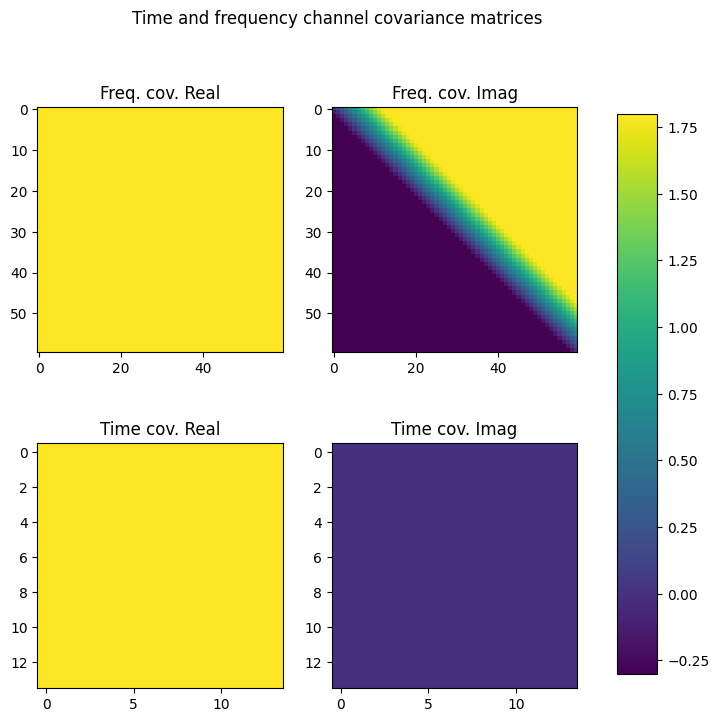

In [23]:
FREQ_COV_MAT = np.load('freq_cov_mat_60.npy')
TIME_COV_MAT = np.load('time_cov_mat_60.npy')
# SPACE_COV_MAT = np.load('space_cov_mat.npy')

fig, ax = plt.subplots(2,2, figsize=(8,8))
fig.suptitle("Time and frequency channel covariance matrices")

ax[0,0].set_title("Freq. cov. Real")
im = ax[0,0].imshow(FREQ_COV_MAT.real, vmin=-0.3, vmax=1.8)
ax[0,1].set_title("Freq. cov. Imag")
im = ax[0,1].imshow(FREQ_COV_MAT.imag, vmin=-0.3, vmax=1.8)

ax[1,0].set_title("Time cov. Real")
im = ax[1,0].imshow(TIME_COV_MAT.real, vmin=-0.3, vmax=1.8)
ax[1,1].set_title("Time cov. Imag")
im = ax[1,1].imshow(TIME_COV_MAT.imag, vmin=-0.3, vmax=1.8)

# ax[2,0].set_title("Space cov. Real")
# im = ax[2,0].imshow(SPACE_COV_MAT.real, vmin=-0.3, vmax=1.8)
# ax[2,1].set_title("Space cov. Imag")
# im = ax[2,1].imshow(SPACE_COV_MAT.imag, vmin=-0.3, vmax=1.8)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax);


In [24]:
FREQ_COV_MAT = np.load('freq_cov_mat_60.npy')
TIME_COV_MAT = np.load('time_cov_mat_60.npy')
# SPACE_COV_MAT = np.load('space_cov_mat.npy')
freq_cov_mat = tf.constant(FREQ_COV_MAT, tf.complex64)
time_cov_mat = tf.constant(TIME_COV_MAT, tf.complex64)

print(freq_cov_mat.shape, time_cov_mat.shape)  # Should be (60, 60), (14, 14)

lmmse_int_freq_first = LMMSEInterpolator(resource_grid.pilot_pattern, 
                                         time_cov_mat, 
                                         freq_cov_mat, 
                                         order='t-f')
channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

(60, 60) (14, 14)


In [25]:
class RawChannelEstimator(Layer):
    """
    Real-domain raw channel estimates H_raw = Y ⊙ X_p* only at pilot positions
    """
    def __init__(self, resource_grid, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots
        
    def call(self, inputs):
        """
        Args:
            inputs: [y_rg, x_rg]
                y_rg: [batch, num_rx, num_rx_ant, ofdm, fft, 2] where last dim is [I, Q]
                x_rg: [batch, num_tx, num_tx_stream, ofdm, fft, 2] where last dim is [I, Q]
        Returns:
            h_raw: [batch, num_rx, num_rx_ant, ofdm, fft, 2] 
                   sparse raw channel estimates with values only at pilot positions
        """
        y_rg, x_rg = inputs
        
        # Initialize zeros (same shape as y_rg)
        h_raw = tf.zeros_like(y_rg, dtype=self.dtype)
        
        y_squeezed = tf.squeeze(y_rg, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        x_squeezed = tf.squeeze(x_rg, axis=1)  # [batch, num_tx_stream, ofdm, fft, 2]
        
        # Extract pilots using the indices (indices only cover first 4 dims, not I/Q)
        y_pilots = tf.gather_nd(y_squeezed, self._pilot_ind)  # [batch, num_pilots, 2]
        x_pilots = tf.gather_nd(x_squeezed, self._pilot_ind)  # [batch, num_pilots, 2]
        
        # Split into I and Q
        y_I = y_pilots[..., 0]  # [batch, num_pilots]
        y_Q = y_pilots[..., 1]
        x_I = x_pilots[..., 0]
        x_Q = x_pilots[..., 1]
        
        # Compute H_raw = Y ⊙ X_p* in real domain: (a+bi)(c-di) = (ac+bd) + (bc-ad)i
        h_raw_I = y_I * x_I + y_Q * x_Q
        h_raw_Q = y_Q * x_I - y_I * x_Q 
        h_raw_pilots = tf.stack([h_raw_I, h_raw_Q], axis=-1) # [batch, num_pilots, 2]
        
        h_raw_squeezed = tf.squeeze(h_raw, axis=1)  # [batch, num_rx_ant, ofdm, fft, 2]
        h_raw_updated = tf.tensor_scatter_nd_update(
            h_raw_squeezed, 
            self._pilot_ind, 
            h_raw_pilots
        )
        
        h_raw = tf.expand_dims(h_raw_updated, axis=1)  # [batch, num_rx, num_rx_ant, ofdm, fft, 2]
        
        return h_raw  


Raw_channel_estimator = RawChannelEstimator(resource_grid)

### Test Definition

In [26]:
## Transmitter
binary_source = BinarySource()

# QAM mapper baseline
# mapper = Mapper("qam", num_bits_per_symbol)
# rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
# channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

mapper = MapperReal("qam", num_bits_per_symbol)
rg_mapper = ResourceGridMapper(resource_grid)  # This should work
channel = OFDMChannelReal(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiver()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements


In [27]:
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
z = tf.random.normal(shape=(batch_size, 1, 14, 128))

## Transmitter
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

# Map bits to QAM symbols
x = mapper(c)
print("x shape: ", x.shape, x.dtype)

# Map the QAM symbols to a resource grid
x = tf.complex(x[...,0], x[...,1])
x_rg = rg_mapper(x)
x_rg = tf.stack([tf.math.real(x_rg), tf.math.imag(x_rg)], axis=-1)
print("x_rg shape: ", x_rg.shape, x_rg.dtype)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
print("no shape: ", no.shape, no_.dtype)
y,h = channel(x_rg, no_)
print("y shape: ", y.shape, y.dtype)
y_p = rg_util.extract_pilots(y)
x_p = rg_util.extract_pilots(x_rg)
print("y_p shape: ", y_p.shape, y_p.dtype)
print("x_p shape: ", x_p.shape, x_p.dtype)

# channel estimation
y_complex = tf.complex(y[..., 0], y[..., 1])
h_hat, _ = channel_estimator(y_complex, no_) # (128, 1, 1, 1, 1, 14, 128)
h_hat = h_hat[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128, 2)
h_hat = add_nulled_subcarriers(h_hat)
h_hat = tf.stack([tf.math.real(h_hat), tf.math.imag(h_hat)], axis=-1)
print("h_hat shape: ", h_hat.shape, h_hat.dtype)

h_raw = Raw_channel_estimator([y, x_rg])
print("h_raw shape: ", h_raw.shape, h_raw.dtype)

######################################
## Receiver
# The neural receover computes LLRs from the frequency domain received symbols and N0
llr = neural_receiver([y, x_p, h_raw])
print("llr shape: ", llr.shape, llr.dtype)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr) # 1392 from 1792 (14*128)
print("LLRs before reshape: ", llr.shape, llr.dtype)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape, llr.dtype)

# h_hat = RemoveNulledSubcarriers(resource_grid)(h) # Extract non-null subcarriers
# print("h_hat_perfect shape: ", h_hat.shape)
# x_hat, no_eff = LMMSEEqualizer(resource_grid, stream_manager, )(y, h_hat, 0.0, no) # LMMSE equalization
# no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
# print("x_hat: ", x_hat.shape)
# llr = Demapper("app", "qam", num_bits_per_symbol)(x_hat, no_eff_) # Demapping
# print("LLRs: ", llr.shape)

# h_hat, err_var = LSChannelEstimator(resource_grid, interpolation_type="nn")(y, no) # LS channel estimation with nearest-neighbor
# print("h_hat_LS shape: ", h_hat.shape)
# x_hat, no_eff = LMMSEEqualizer(resource_grid, stream_manager, )(y, h_hat, err_var, no) # LMMSE equalization
# no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
# print("x_hat: ", x_hat.shape)
# llr = Demapper("app", "qam", num_bits_per_symbol)(x_hat, no_eff_) # Demapping
# print("LLRs: ", llr.shape)

c shape:  (256, 1, 1, 4320)
x shape:  (256, 1, 1, 720, 2) <dtype: 'float32'>
x_rg shape:  (256, 1, 1, 14, 60, 2) <dtype: 'float32'>
no shape:  (256,) <dtype: 'float32'>
y shape:  (256, 1, 1, 14, 60, 2) <dtype: 'float32'>
y_p shape:  (256, 1, 1, 14, 60, 2) <dtype: 'float32'>
x_p shape:  (256, 1, 1, 14, 60, 2) <dtype: 'float32'>
h_hat shape:  (256, 1, 1, 14, 72, 2) <dtype: 'float32'>
h_raw shape:  (256, 1, 1, 14, 60, 2) <dtype: 'float32'>


2026-05-07 10:19:16.086584: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-07 10:19:16.299775: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


llr shape:  (256, 14, 60, 6) <dtype: 'float32'>
LLRs before reshape:  (256, 1, 1, 720, 6) <dtype: 'float32'>
Post RG-demapper LLRs:  (256, 1, 1, 4320) <dtype: 'float32'>


In [28]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: -5.72E-01 bit


### End-to-end System as a Keras Model <a class="anchor" id="End-to-end-System-as-a-Keras-Model"></a>

In [29]:
# real-domain
class E2ESystem(Model):
    def __init__(self, resource_grid, stream_manager, rg_util, 
                 n_total, k_total, num_cbs, k_per_cb, n_per_cb,
                 training=False, use_fec=True):
        super().__init__()
        self._training = training
        self._use_fec = use_fec
        self._n_total = n_total
        self._k_total = k_total
        self._num_cbs = num_cbs
        self._k_per_cb = k_per_cb
        self._n_per_cb = n_per_cb
        self.y_gen = None
        self.y_real = None
        self.raw_channel_estimator = RawChannelEstimator(resource_grid)
        self.channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        if not training:
            self._encoder = LDPC5GEncoder(k_per_cb, n_per_cb)
            self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)
        
        # Trainable constellation
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.constellation = Constellation("custom",
                                    num_bits_per_symbol,
                                    points=qam_points,
                                    normalize=True,
                                    center=True)
        self.points_r = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_i = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_r.assign(tf.math.real(qam_points))
        self.points_i.assign(tf.math.imag(qam_points))

        self._mapper_real = MapperReal(constellation=self.constellation)
        self._rg_mapper_real = ResourceGridMapper(resource_grid)        

        ######################################
        ## Channel
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannelReal(cdl, resource_grid, normalize_channel=True, return_channel=True)

        self._gan_channel = GANGenerator()

        ######################################
        ## Receiver
        self._neural_receiver = NeuralReceiver()
        self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager)
        self._rg_util = rg_util
    
    @tf.function
    def call(self, batch_size, ebno_db, use_gan_channel=False):
        
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)

        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, self._n_total])
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, self._k_total])
            b_cbs = tf.reshape(b, [batch_size, 1, 1, self._num_cbs, self._k_per_cb])
            c_cbs = tf.map_fn(lambda x: self._encoder(x), b_cbs)
            c = tf.reshape(c_cbs, [batch_size, 1, 1, self._n_total])
        
        # Modulation
        points = tf.complex(self.points_r, self.points_i)
        self.constellation.points = points
        x = self._mapper_real(c)
        
        x = tf.complex(x[...,0], x[...,1])
        x_rg = self._rg_mapper_real(x) 
        x_rg = tf.stack([tf.math.real(x_rg), tf.math.imag(x_rg)], axis=-1)

        ######################################
        ## Channel
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y, h = self._real_channel(x_rg, no_)

        self.y_real = y
        
        # channel estimation
        h_hat = self.raw_channel_estimator([self.y_real, x_rg])
        
        # extract pilots
        y_p = self._rg_util.extract_pilots(self.y_real)
        x_p = self._rg_util.extract_pilots(x_rg)

        ### ----------------- GAN channel
        if use_gan_channel: 
            y_complex = tf.complex(y[..., 0], y[..., 1])
            h_hat_lmmse, _ = self.channel_estimator(y_complex, no_)
            h_hat_lmmse = h_hat_lmmse[:,:,:,0,0,:,:]
            h_hat_lmmse = tf.stop_gradient(add_nulled_subcarriers(h_hat_lmmse))
            h_hat_lmmse = tf.stack([tf.math.real(h_hat_lmmse), tf.math.imag(h_hat_lmmse)], axis=-1)

            z = tf.random.normal([batch_size, 14, 128, noise_dim])
            
            pilots = tf.concat([y_p, x_p], axis=2)
            h_freq = h[:,:,:,0,0,:,:,:]
            
            condition = h_hat_lmmse
            y = self._gan_channel(z, x_rg, condition)
            self.y_gen = y
            
        ######################################
        ## Receiver    
        llr = self._neural_receiver([y, x_p, h_hat])
        llr = insert_dims(llr, 2, 1)
        llr = self._rg_demapper(llr)
        llr = tf.reshape(llr, [batch_size, 1, 1, self._n_total])

        if self._training:
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            if use_gan_channel:
                return rate, x_rg, self.y_gen, self.y_real, h_freq, h_hat_lmmse, pilots, no_
            else:
                return rate
        else:
            if self._use_fec:
                llr_cbs = tf.reshape(llr, [batch_size, 1, 1, self._num_cbs, self._n_per_cb])
                b_hat_cbs = tf.map_fn(lambda x: self._decoder(x), llr_cbs)
                b_hat = tf.reshape(b_hat_cbs, [batch_size, 1, 1, self._k_total])
            else:
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat

#### Conventional Receiver

In [ ]:
class E2EConvSystem(Model):
    def __init__(self, system, training=False, use_fec=True):
        super().__init__()
        self._system = system
        self._training = training
        self._use_fec = use_fec

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training and use_fec:
            self._encoder = LDPC5GEncoder(k, n)
        self._mapper = Mapper("qam", num_bits_per_symbol)
        self._rg_mapper = ResourceGridMapper(resource_grid)

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of `system`
        if system == 'baseline-perfect-csi': # Perfect CSI
            self._removed_null_subc = RemoveNulledSubcarriers(resource_grid)
        elif system == 'baseline-ls-estimation': # LS estimation
            self._ls_est = LSChannelEstimator(resource_grid, interpolation_type="nn")
        # Components required by both baselines
        self._lmmse_equ = LMMSEEqualizer(resource_grid, stream_manager, )
        self._demapper = Demapper("app", "qam", num_bits_per_symbol)
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training and use_fec:
            self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)

    @tf.function
    def call(self, batch_size, ebno_db):

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n])
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k])
            c = self._encoder(b)

        # Modulation
        x = self._mapper(c)
        x_rg = self._rg_mapper(x)

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._channel(x_rg, no_)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of ``system``
        if self._system == 'baseline-perfect-csi':
            h_hat = self._removed_null_subc(h) # Extract non-null subcarriers
            err_var = 0.0 # No channel estimation error when perfect CSI knowledge is assumed
        elif self._system == 'baseline-ls-estimation':
            h_hat, err_var = self._ls_est(y, no) # LS channel estimation with nearest-neighbor
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no) # LMMSE equalization
        no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
        llr = self._demapper(x_hat, no_eff_) # Demapping
        
        # Outer coding is not needed if the information rate is returned or FEC is disabled
        if self._use_fec:
            b_hat = self._decoder(llr)
        else:
            # Hard decision on LLRs without FEC
            b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
        return b, b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

#### Hybrid

In [ ]:
class E2ESystem(Model):
    def __init__(self, training=False, use_fec=True):
        super().__init__()
        self._training = training
        self._use_fec = use_fec
        
        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        # Encoder
        self._encoder = LDPC5GEncoder(k, n)
        
        # Trainable constellation
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=qam_points,
                                           normalize=True,
                                           center=True)
        # To make the constellation trainable, we need to create seperate
        # variables for the real and imaginary parts
        self.points_r = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_i = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_r.assign(tf.math.real(qam_points))
        self.points_i.assign(tf.math.imag(qam_points))

        self._mapper = Mapper(constellation=self.constellation)
        
        self._rg_mapper = ResourceGridMapper(resource_grid)         
        
        ######################################
        ## Channel
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)
        
        ######################################
        ## Receiver
        self._hybrid_receiver = HybridReceiver(
            resource_grid=resource_grid,
            stream_manager=stream_manager,
            num_bits_per_symbol=num_bits_per_symbol
        )
        
        # Final hard decoder for inference only
        if not training:
            self._hard_decoder = LDPC5GDecoder(self._encoder, hard_out=True, cn_update='offset-minsum', return_infobits=True)
    
    @tf.function
    def call(self, batch_size, ebno_db):
        
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)
        
        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n]) # u=4176*2
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k]) # k=4176
            c = self._encoder(b) # u=n=4176*2
        
        points = tf.complex(self.points_r, self.points_i)
        self.constellation.points = points
        
        x = self._mapper(c)
        
        x_rg = self._rg_mapper(x)
        
        ######################################
        ## Channel
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y, h = self._real_channel(x_rg, no_)
        
        ######################################
        ## Receiver    
        # Hybrid receiver returns demapper LLRs (single pass)
        llr = self._hybrid_receiver([y, no])  # Returns [batch, n]
        llr = tf.reshape(llr, [batch_size, 1, 1, n])
        
        if self._training:
            # Training: compute binary cross-entropy loss on demapper output
            bce = tf.nn.sigmoid_cross_entropy_with_logits(
                labels=tf.cast(c, tf.float32), 
                logits=llr
            )
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            return rate
        else:
            # Outer coding is not needed if the information rate is returned or FEC is disabled
            if self._use_fec:
                b_hat = self._hard_decoder(llr) # llr=8352
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # ground truth and reconstructed bits returned for BER/BLER computation

## Metric

In [30]:
def compute_psd_line(y):
    y = tf.squeeze(y, axis=[1,2])  # Shape: [batch, 14, 128, 2]
    magnitude = tf.sqrt(y[..., 0]**2 + y[..., 1]**2)  # |H| = sqrt(I² + Q²)
    power_spectrum = magnitude ** 2  # Power spectrum |H|²
    power_db = 10 * tf.math.log(power_spectrum + 1e-10) / tf.math.log(10.0)
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])
    
    return tf.reduce_mean(power_db_shifted, axis=1)  # Average over OFDM symbols

def compute_psd(y):
    y = tf.squeeze(y, axis=[1,2])  # Shape: [batch, 14, 128, 2]
    
    magnitude = tf.sqrt(y[..., 0]**2 + y[..., 1]**2)  # |H| = sqrt(I² + Q²)
    power_spectrum = magnitude ** 2  # Power spectrum |H|²
    power_db = 10 * tf.math.log(power_spectrum + 1e-10) / tf.math.log(10.0)
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])
    
    # Average over batch for 2D visualization
    psd = tf.reduce_mean(power_db_shifted, axis=0)  # Shape: [14, 128]
    
    return psd

def plot_psd_line(psd_real, psd_fake):
    # Convert to NumPy and average over batch
    psd_real_np = psd_real.numpy().mean(axis=0)  # Shape: [128]
    psd_fake_np = psd_fake.numpy().mean(axis=0)  # Shape: [128]
    
    # Frequency axis (normalized subcarriers)
    freq_axis = np.linspace(-0.5, 0.5, psd_real_np.shape[-1])  # Normalized frequencies
    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(freq_axis, psd_real_np, label="Real PSD", linewidth=2)
    plt.plot(freq_axis, psd_fake_np, label="Generated PSD", linewidth=2)
    plt.xlabel("Normalized Frequency")
    plt.ylabel("PSD (dB)")
    plt.title("Power Spectral Density of OFDM Signal")
    plt.legend()
    plt.grid()
    plt.show()

def plot_psd(psd_real, psd_generated):
    vmin = min(np.min(psd_real.numpy()), np.min(psd_generated.numpy()))
    vmax = max(np.max(psd_real.numpy()), np.max(psd_generated.numpy()))

    plt.figure(figsize=(12, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(psd_real.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Real PSD')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(psd_generated.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Generated PSD')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()


In [31]:
def plot_phase_amp_distribution(real_y, generated_y):
    # Average over batch and OFDM symbols, keep subcarriers (freq)
    real_avg = tf.reduce_mean(real_y, axis=[0, 1, 2, 3]).numpy()  # [128, 2]
    gen_avg = tf.reduce_mean(generated_y, axis=[0, 1, 2, 3]).numpy()  # [128, 2]
    
    # Convert [I, Q] to magnitude and phase
    real_mag = np.sqrt(real_avg[..., 0]**2 + real_avg[..., 1]**2)
    gen_mag = np.sqrt(gen_avg[..., 0]**2 + gen_avg[..., 1]**2)
    real_phase = np.arctan2(real_avg[..., 1], real_avg[..., 0])
    gen_phase = np.arctan2(gen_avg[..., 1], gen_avg[..., 0])
    
    freq_axis = np.linspace(-0.5, 0.5, len(real_mag))
    
    # Magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, 20*np.log10(real_mag + 1e-10), 'r-', label='Channel')
    plt.plot(freq_axis, 20*np.log10(gen_mag + 1e-10), 'b-', label='GAN')
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude [dB]')
    plt.legend()
    plt.grid()
    
    # Phase plot
    plt.subplot(2, 1, 2)
    plt.plot(freq_axis, real_phase, 'r-', label='Channel', markersize=3)
    plt.plot(freq_axis, gen_phase, 'b-', label='GAN', linewidth=2)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Phase [rad]')
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()

## Training Parameters

In [65]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionnary storing the evaluation results
BLER = {}
BER = {}

In [66]:
def gradient_penalty(disc, y_real, y_fake, x_real, condition):
    lamb = 10
    batchlen = tf.shape(y_real)[0]  # batch size of y_real or y_fake
    
    epsilon = tf.random.uniform([batchlen, 1,1,1,1,1], minval=0, maxval=1, dtype=tf.float32) # interpolation factor (0-1)
    # epsilon = epsilon[:, None, None, None, None]
    
    # Interpolating between real and fake post-fft y
    y_real = tf.cast(y_real, tf.float32)
    y_fake = tf.cast(y_fake, tf.float32)
    interpolated = epsilon * y_real + (1 - epsilon) * y_fake
    
    # Gradient calculation
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        D_logit_pred = disc(interpolated, x_real, condition)

    grads = gp_tape.gradient(D_logit_pred, interpolated)

    # num_elements = tf.reduce_prod(tf.shape(grads)[1:])
    grad_norms = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3,4,5])) # / tf.cast(num_elements, tf.float32) )
    # print(tf.reduce_mean(grads), tf.reduce_mean(grad_norms))
    
    gp = lamb * tf.reduce_mean(tf.square(grad_norms - 1))
    # gp = lamb * tf.reduce_mean(tf.clip_by_value(grad_norms - 1., 0., np.infty)**2)
    
    return gp, tf.reduce_mean(grad_norms)

In [67]:
def compute_ldpc_params(resource_grid, num_bits_per_symbol, coderate):
    n_total = int(resource_grid.num_data_symbols * num_bits_per_symbol)
    k_total = int(n_total * coderate)
    max_k = 8448
    if k_total <= max_k:
        num_cbs = 1
        k_per_cb = k_total
        n_per_cb = n_total
    else:
        num_cbs = int(np.ceil(k_total / max_k))
        k_per_cb = k_total // num_cbs
        n_per_cb = int(k_per_cb / coderate)
    return n_total, k_total, num_cbs, k_per_cb, n_per_cb

In [68]:
# model = E2ESystem(training=True, use_fec=True)
# eval_model = E2ESystem(training=False, use_fec=True)

# --- Training (128 FFT) ---
n_total, k_total, num_cbs, k_per_cb, n_per_cb = compute_ldpc_params(
    resource_grid, num_bits_per_symbol, coderate)

model = E2ESystem(resource_grid, stream_manager, rg_util,
                  n_total, k_total, num_cbs, k_per_cb, n_per_cb,
                  training=True)
# --- Eval on same grid ---
eval_model = E2ESystem(resource_grid, stream_manager, rg_util,
                       n_total, k_total, num_cbs, k_per_cb, n_per_cb,
                       training=False)

WG = GANGenerator()
WD = GANDiscriminator()

list_D = []
list_G = []
list_W = []

# lr_schedule_D = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=0.00005,
#     decay_steps=1000,
#     decay_rate=0.9, # 0.93
#     staircase=True)

lr_G = 0.0001
lr_D = 0.00005
epoch = 4000

optimizer_G = tf.keras.optimizers.Adam(lr_G, beta_1=0.5, beta_2=0.9)
optimizer_D = tf.keras.optimizers.Adam(lr_D, beta_1=0.5, beta_2=0.9)
optimizer = tf.keras.optimizers.legacy.Adam() # default lr 0.001

In [69]:
@tf.function
def WGAN_train_step(y_real, x_rg, condition):
    z = tf.random.normal([batch_size, 14, 128, noise_dim])
    y_fake = WG(z, x_rg, condition)

    # Train Discriminator
    for j in range(1): # DISCRIMINATOR_TRAININGS_PER_GENERATOR_TRAINING
        with tf.GradientTape() as tape_D:
            d_real = WD(y_real, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)

            gp, grad_norm = gradient_penalty(WD, y_real, y_fake, x_rg, condition)
            loss_D = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp # maximize d_real

            # TODO: test mse
            # loss_D = tf.reduce_mean(tf.square(d_fake -d_real)) + gp

            # TODO: test hinge loss
            # loss_D = tf.reduce_mean(tf.nn.relu(1.0 - d_real)) + tf.reduce_mean(tf.nn.relu(1.0 + d_fake)) + gp

            # watched_vars = tape_D.watched_variables()
            # tf.print("Tape_D is watching:", len(watched_vars), "variables")
            # for var in watched_vars:
            #     tf.print("Watched:", var.name)
            
        grads_D = tape_D.gradient(loss_D, WD.trainable_variables)
        optimizer_D.apply_gradients(zip(grads_D, WD.trainable_variables))

    # Train Generator
    for k in range(1):
        with tf.GradientTape() as tape_G:
            y_fake = WG(z, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)
            
            loss_G = -tf.reduce_mean(d_fake) # maximize d_fake

            # watched_vars = tape_G.watched_variables()
            # tf.print("Tape_G is watching:", len(watched_vars), "variables")
            # for var in watched_vars:
            #     tf.print("Watched:", var.name)
                
        grads_G = tape_G.gradient(loss_G, WG.trainable_variables)
        optimizer_G.apply_gradients(zip(grads_G, WG.trainable_variables))
    
    return d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake

In [70]:
@tf.function
def E2E_train__tx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, (Constellation, Mapper)):
            layer.trainable = True  
        else:
            layer.trainable = False  
    tx_weights = model.trainable_weights
    # for w in tx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate, _, y_gen, y_real, h_freq, _, _, _ = model(batch_size, ebno_db, use_gan_channel=True) # rate, self.x_rg, self.y_gen, self.y_real, self.h_freq, no_
        loss = -rate 
    
    grads_tx = tape.gradient(loss, tx_weights)
    optimizer.apply_gradients(zip(grads_tx, tx_weights))
    
    return loss, y_gen, y_real, grads_tx

@tf.function
def E2E_train__rx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, NeuralReceiver):
            layer.trainable = True 
        else:
            layer.trainable = False
    rx_weights = model.trainable_weights
    # for w in rx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads_rx = tape.gradient(loss, rx_weights)
    optimizer.apply_gradients(zip(grads_rx, rx_weights))

    return loss, grads_rx

## Training the WGAN

  0%|          | 0/4001 [00:00<?, ?it/s]

Epoch [0/4000] ebno(db):11.1205 w_d:-0.0172 gp: 9.9568, grad_norm: 0.0022 Loss_D: 9.9568 Loss_G: -0.0512, sse: 257126.6562
0.012966004 0.00010610917


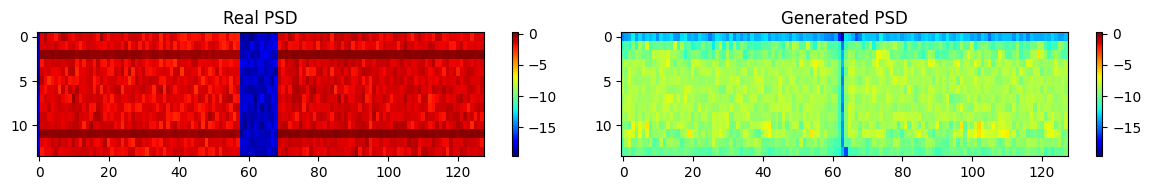

Epoch [100/4000] ebno(db):6.4995 w_d:-0.2362 gp: 9.8314, grad_norm: 0.0085 Loss_D: 9.8853 Loss_G: 0.3172, sse: 302427.3125
Epoch [200/4000] ebno(db):8.2508 w_d:-0.1168 gp: 9.3261, grad_norm: 0.0343 Loss_D: 9.3591 Loss_G: -0.9491, sse: 849211.0000
Epoch [300/4000] ebno(db):12.6923 w_d:-0.5051 gp: 8.7441, grad_norm: 0.0650 Loss_D: 8.9246 Loss_G: 0.6272, sse: 294363.9375
Epoch [400/4000] ebno(db):7.6796 w_d:-0.6140 gp: 8.7086, grad_norm: 0.0669 Loss_D: 9.3468 Loss_G: 2.3993, sse: 634097.8750
Epoch [500/4000] ebno(db):6.7342 w_d:-0.5190 gp: 8.2668, grad_norm: 0.0910 Loss_D: 8.4508 Loss_G: 2.6215, sse: 424860.8125
Epoch [600/4000] ebno(db):6.0583 w_d:-0.3906 gp: 7.6081, grad_norm: 0.1279 Loss_D: 7.7756 Loss_G: 9.0322, sse: 409653.2500
Epoch [700/4000] ebno(db):0.9527 w_d:-0.6587 gp: 5.6640, grad_norm: 0.2486 Loss_D: 6.4516 Loss_G: 18.8106, sse: 486904.0625
Epoch [800/4000] ebno(db):1.7446 w_d:-0.4325 gp: 3.4660, grad_norm: 0.4165 Loss_D: 3.8783 Loss_G: 34.2853, sse: 483070.1875
Epoch [900/4

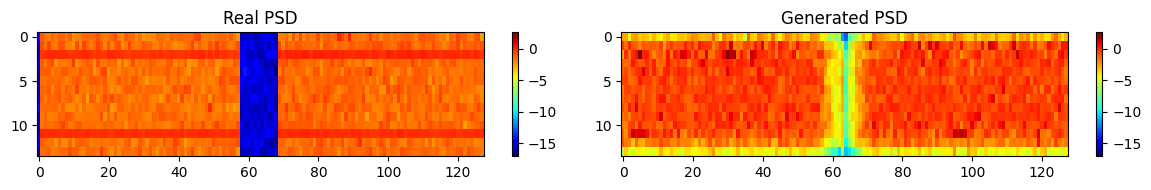

Epoch [1100/4000] ebno(db):0.9226 w_d:-1.4265 gp: 1.5974, grad_norm: 0.6104 Loss_D: 3.8124 Loss_G: 51.2550, sse: 446802.0625
Epoch [1200/4000] ebno(db):1.6501 w_d:-1.2243 gp: 1.5112, grad_norm: 0.6210 Loss_D: 4.4790 Loss_G: 44.5428, sse: 363538.6562
Epoch [1300/4000] ebno(db):6.4857 w_d:-0.3314 gp: 1.3242, grad_norm: 0.6407 Loss_D: 1.5634 Loss_G: 43.5972, sse: 212713.5312
Epoch [1400/4000] ebno(db):4.4327 w_d:-0.3336 gp: 1.2707, grad_norm: 0.6465 Loss_D: 2.5792 Loss_G: 40.3836, sse: 150622.5938
Epoch [1500/4000] ebno(db):5.4587 w_d:-0.5357 gp: 1.5891, grad_norm: 0.6025 Loss_D: 2.6155 Loss_G: 32.8191, sse: 108610.5859
Epoch [1600/4000] ebno(db):6.3460 w_d:-1.5194 gp: 1.8434, grad_norm: 0.5720 Loss_D: 2.6170 Loss_G: 20.5504, sse: 78832.2344
Epoch [1700/4000] ebno(db):2.9484 w_d:-1.3342 gp: 1.8334, grad_norm: 0.5734 Loss_D: 4.5465 Loss_G: 10.9126, sse: 96075.7812
Epoch [1800/4000] ebno(db):2.6392 w_d:-1.5357 gp: 2.0349, grad_norm: 0.5493 Loss_D: 4.3257 Loss_G: 4.1716, sse: 87821.5625
Epoc

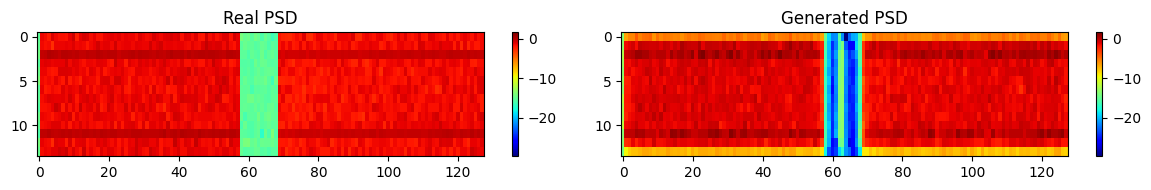

Epoch [2100/4000] ebno(db):1.2562 w_d:-1.8011 gp: 1.8335, grad_norm: 0.5724 Loss_D: 7.4652 Loss_G: -9.6296, sse: 97759.0156
Epoch [2200/4000] ebno(db):5.8044 w_d:-0.1165 gp: 1.8975, grad_norm: 0.5648 Loss_D: 4.1109 Loss_G: -9.0030, sse: 62577.0312
Epoch [2300/4000] ebno(db):12.3098 w_d:-0.4602 gp: 1.4544, grad_norm: 0.6192 Loss_D: 1.9128 Loss_G: -11.4993, sse: 39271.0977
Epoch [2400/4000] ebno(db):8.7395 w_d:0.0844 gp: 1.9217, grad_norm: 0.5620 Loss_D: 1.9983 Loss_G: -8.3427, sse: 46634.5508
Epoch [2500/4000] ebno(db):10.6108 w_d:-0.3905 gp: 1.8899, grad_norm: 0.5654 Loss_D: 2.2447 Loss_G: -8.2400, sse: 38434.0625
Epoch [2600/4000] ebno(db):13.6419 w_d:0.1263 gp: 1.8251, grad_norm: 0.5731 Loss_D: 3.0421 Loss_G: -9.1035, sse: 51309.2070
Epoch [2700/4000] ebno(db):0.2166 w_d:-2.1538 gp: 1.9266, grad_norm: 0.5612 Loss_D: 4.9383 Loss_G: -6.2251, sse: 106059.8906
Epoch [2800/4000] ebno(db):10.4182 w_d:0.0025 gp: 2.0656, grad_norm: 0.5457 Loss_D: 2.5386 Loss_G: -3.9692, sse: 45773.5625
Epoch

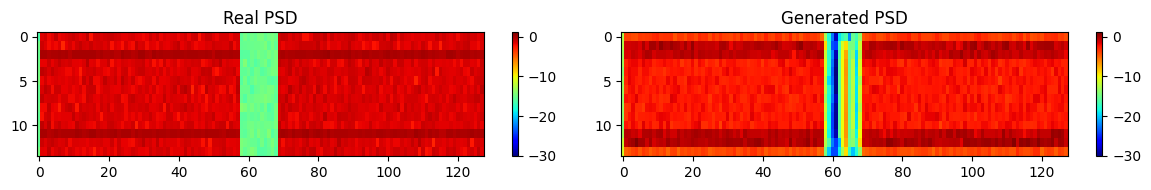

Epoch [3100/4000] ebno(db):5.7230 w_d:-0.0664 gp: 1.6302, grad_norm: 0.5966 Loss_D: 2.5358 Loss_G: -5.9901, sse: 61727.2461
Epoch [3200/4000] ebno(db):3.5767 w_d:-0.4557 gp: 1.8393, grad_norm: 0.5713 Loss_D: 3.0016 Loss_G: -5.1645, sse: 74033.8828
Epoch [3300/4000] ebno(db):10.2362 w_d:-0.3294 gp: 1.5081, grad_norm: 0.6132 Loss_D: 5.5689 Loss_G: -3.4498, sse: 55126.9297
Epoch [3400/4000] ebno(db):9.8684 w_d:-0.0712 gp: 1.6606, grad_norm: 0.5935 Loss_D: 2.4563 Loss_G: -3.5444, sse: 49758.3594
Epoch [3500/4000] ebno(db):8.7132 w_d:0.0372 gp: 2.0909, grad_norm: 0.5436 Loss_D: 2.1360 Loss_G: -3.3680, sse: 45732.9336
Epoch [3600/4000] ebno(db):9.5149 w_d:-0.3619 gp: 2.0992, grad_norm: 0.5421 Loss_D: 3.9997 Loss_G: -4.7115, sse: 47638.9023
Epoch [3700/4000] ebno(db):0.6773 w_d:-1.9692 gp: 1.6244, grad_norm: 0.5978 Loss_D: 10.6475 Loss_G: -7.6473, sse: 110565.4688
Epoch [3800/4000] ebno(db):2.7208 w_d:-0.2209 gp: 1.9092, grad_norm: 0.5633 Loss_D: 2.2394 Loss_G: -6.3721, sse: 80293.7969
Epoch 

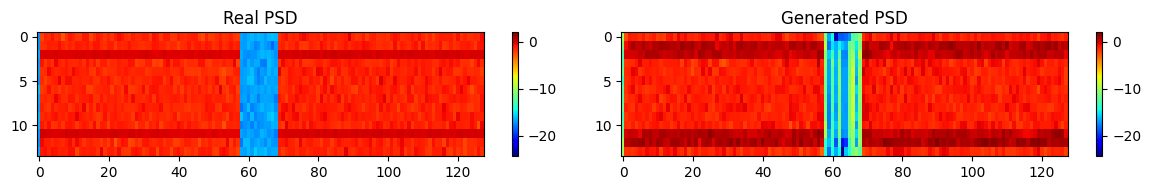

In [69]:
offset = 0
for i in tqdm(range(offset, epoch+1)):    
    # Sampling a batch of SNRs
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    # ebno_db = tf.constant(10.0, tf.float32)
    
    _, x_rg, _, y_real, h_freq, h_hat_lmmse, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)

    condition = h_hat_lmmse

    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
    
    gan_weights_G = WG.get_weights()
    gan_weights_D = WD.get_weights()

    # -----------------------------------------------------------------------     
    list_D.append(loss_D.numpy())
    list_G.append(loss_G.numpy())

    w_dist = tf.reduce_mean(d_real) - tf.reduce_mean(d_fake)  # critic score without GP penalty
    list_W.append(w_dist.numpy())

    if i % 100 == 0: 
        psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
        psd_generated = compute_psd(y_fake)
        sse = tf.reduce_sum(tf.abs(y_real - y_fake)**2)

        print(f"Epoch [{i}/{epoch}] ebno(db):{ebno_db.numpy():.4f} w_d:{w_dist:.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, sse: {sse.numpy():.4f}") 
    
    if i % 1000 == 0:    
        print(np.mean(y_fake), np.mean(y_real))
        
        psd_real_line = compute_psd_line(y_real)
        psd_generated_line = compute_psd_line(y_fake)
        # plot_psd_line(psd_real_line, psd_generated_line)
        
        # plot_phase_amp_distribution(y_real, y_fake)

        plot_psd(psd_real, psd_generated)

    if i % 1000 == 0: 
        # save GAN weights
        with open(f'gan_weights/testmse_real_hhat_gan_weights_G_{i}.pkl', 'wb') as f2:
            pickle.dump(gan_weights_G, f2)
        with open(f'gan_weights/testmse_real_hhat_gan_weights_D_{i}.pkl', 'wb') as f3:
            pickle.dump(gan_weights_D, f3)

In [70]:
np.savez(f'losses/testmse_real_hhat_gan_losses.npz', 
         G=np.array(list_G), 
         D=np.array(list_D), 
         W=np.array(list_W))

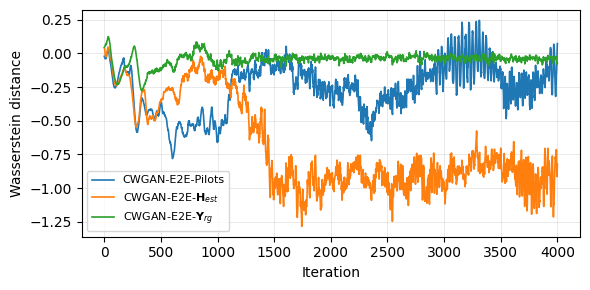

In [71]:
from scipy.ndimage import uniform_filter1d

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

runs = [
    ('losses/testmse_real_pilots_gan_losses.npz',     'CWGAN-E2E-Pilots'),
    ('losses/testmse_real_hhat_gan_losses.npz',        'CWGAN-E2E-$\mathbf{H}_{est}$'),
    ('losses/testmse_real_receivedY_gan_losses.npz', 'CWGAN-E2E-$\mathbf{Y}_{rg}$'),
]

smooth = lambda x: uniform_filter1d(x, size=50)  # adjust window

fig, ax = plt.subplots(figsize=(6, 3))

for run_path, label in runs:
    data = np.load(run_path)
    ax.plot(smooth(data['W']), label=label, linewidth=1.2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Wasserstein distance')
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
# plt.savefig('gan_losses_all.pdf', dpi=300, bbox_inches='tight')

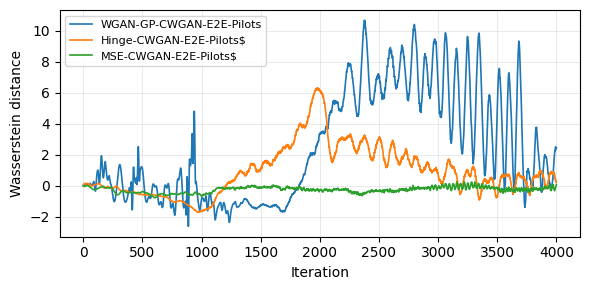

In [72]:
runs = [
    ('losses/real_pilots_gan_losses.npz',     'WGAN-GP-CWGAN-E2E-Pilots'),
    ('losses/real_pilots_hingegan_losses.npz',        'Hinge-CWGAN-E2E-Pilots$'),
    ('losses/testmse_real_pilots_gan_losses.npz', 'MSE-CWGAN-E2E-Pilots$'),
]

smooth = lambda x: uniform_filter1d(x, size=50)  # adjust window

fig, ax = plt.subplots(figsize=(6, 3))

for run_path, label in runs:
    data = np.load(run_path)
    ax.plot(smooth(data['W']), label=label, linewidth=1.2)

ax.set_xlabel('Iteration')
ax.set_ylabel('Wasserstein distance')
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()

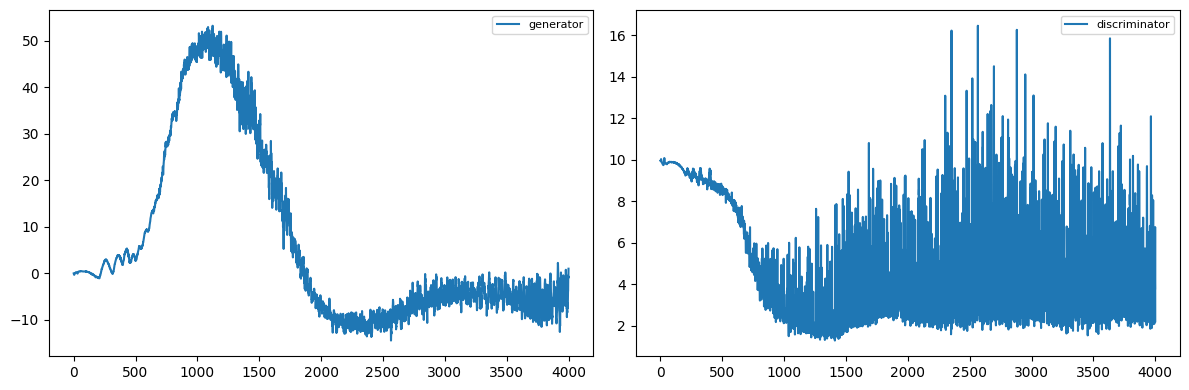

In [73]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

G_L = np.asarray(list_G)
D_L = np.asarray(list_D)
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(G_L, label='generator')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(D_L, label = 'discriminator')
plt.legend()
plt.tight_layout()

# Save the figure
plt.savefig('testmse_real_pilots_gan_losses.png', dpi=300, bbox_inches='tight')

## Joint training

In [74]:
with open('gan_weights/testmse_real_hhat_gan_weights_G_4000.pkl', 'rb') as f:
    g_weights = pickle.load(f)
WG.set_weights(g_weights)
with open('gan_weights/testmse_real_hhat_gan_weights_D_4000.pkl', 'rb') as f:
    d_weights = pickle.load(f)
WD.set_weights(d_weights)

  0%|          | 0/30001 [00:00<?, ?it/s]

Epoch [0/3000] w_d:0.1815 gp: 1.9319, grad_norm: 0.5606 Loss_D: 2.1134 Loss_G: 0.1171, mse: 37596.1094


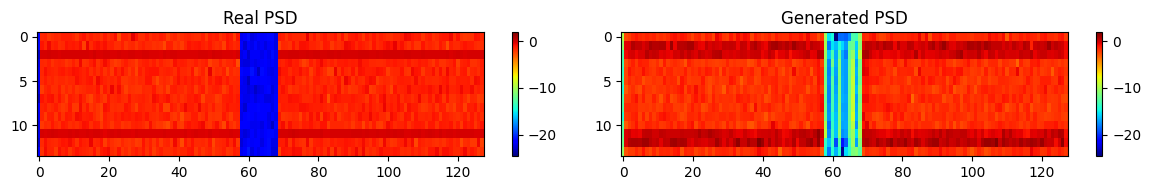

Iteration 0/30000, Eb/No: 14.6384, Loss_tx: 0.4300, Loss_rx: 0.4304
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.0151e-01 | 1.0000e+00 |      268073 |      534528 |          128 |         128 |         0.6 |reached target block errors
Epoch [250/3000] w_d:7.5034 gp: 1.2986, grad_norm: 0.6406 Loss_D: 8.8021 Loss_G: -7.5225, mse: 96145.4141
Epoch [500/3000] w_d:11.3367 gp: 1.4599, grad_norm: 0.6188 Loss_D: 12.7966 Loss_G: -5.3739, mse: 115304.1797


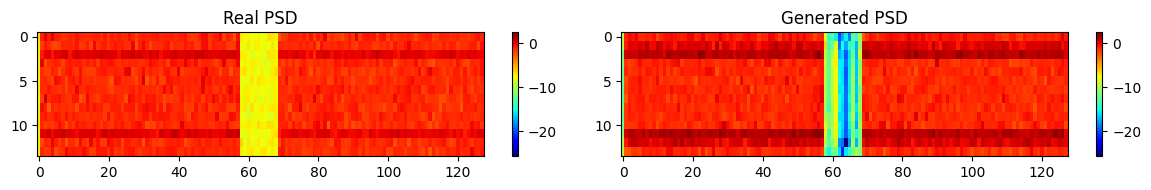

Iteration 5000/30000, Eb/No: 0.2371, Loss_tx: -0.3656, Loss_rx: -0.2912
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 8.6043e-04 | 7.2338e-03 |       24836 |    28864512 |           50 |        6912 |        22.5 |reached target block errors
Epoch [750/3000] w_d:0.6163 gp: 1.5056, grad_norm: 0.6122 Loss_D: 2.1219 Loss_G: 3.1494, mse: 33343.0508
Epoch [1000/3000] w_d:4.9450 gp: 1.4858, grad_norm: 0.6160 Loss_D: 6.4308 Loss_G: 3.1660, mse: 90210.5547


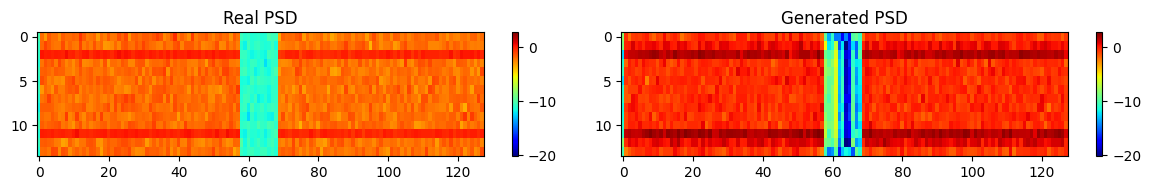

Iteration 10000/30000, Eb/No: 3.6489, Loss_tx: -0.4290, Loss_rx: -0.4448
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 8.7408e-04 | 6.7532e-03 |       27566 |    31537152 |           51 |        7552 |        23.8 |reached target block errors
Epoch [1250/3000] w_d:2.9794 gp: 1.6939, grad_norm: 0.5894 Loss_D: 4.6733 Loss_G: 0.8183, mse: 44537.4336
Epoch [1500/3000] w_d:3.5076 gp: 1.9974, grad_norm: 0.5535 Loss_D: 5.5050 Loss_G: -2.5196, mse: 76527.8281


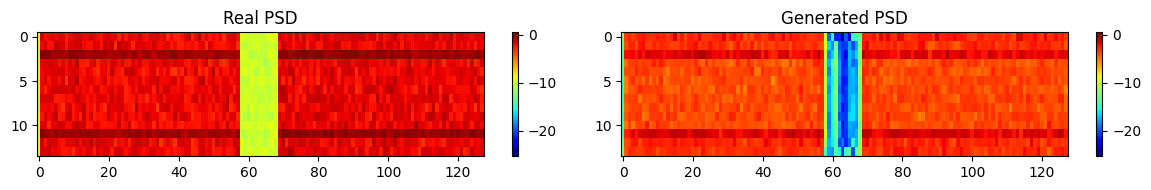

Iteration 15000/30000, Eb/No: 2.5279, Loss_tx: -0.2234, Loss_rx: -0.3993
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.6111e-04 | 5.5804e-03 |       20995 |    37416960 |           50 |        8960 |        26.7 |reached target block errors
Epoch [1750/3000] w_d:3.6605 gp: 1.6248, grad_norm: 0.5980 Loss_D: 5.2852 Loss_G: -1.6422, mse: 41757.9492
Epoch [2000/3000] w_d:1.1911 gp: 2.1783, grad_norm: 0.5335 Loss_D: 3.3694 Loss_G: 2.7478, mse: 42268.8672


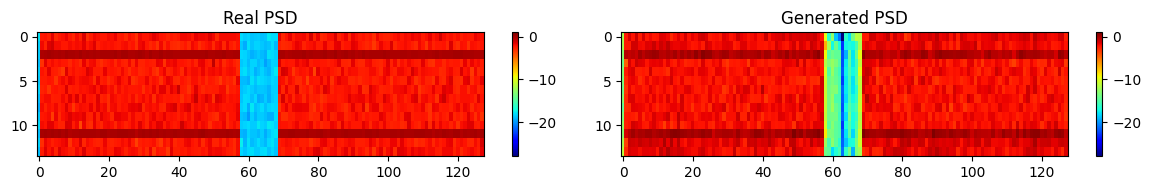

Iteration 20000/30000, Eb/No: 11.2351, Loss_tx: -0.3378, Loss_rx: -0.7575
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 6.8750e-04 | 5.5339e-03 |       26459 |    38486016 |           51 |        9216 |        29.8 |reached target block errors
Epoch [2250/3000] w_d:2.3586 gp: 2.4190, grad_norm: 0.5083 Loss_D: 4.7776 Loss_G: 3.5748, mse: 72815.2266
Epoch [2500/3000] w_d:3.8056 gp: 1.9274, grad_norm: 0.5614 Loss_D: 5.7329 Loss_G: 2.0575, mse: 84852.9922


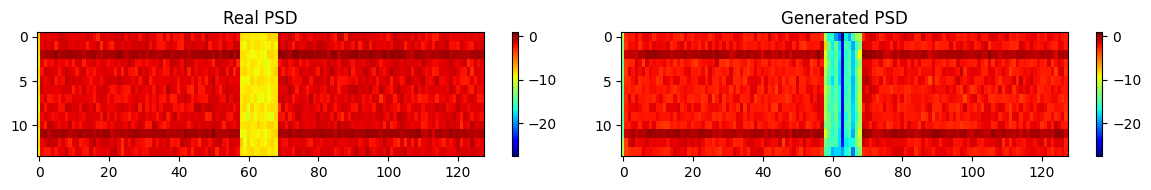

Iteration 25000/30000, Eb/No: 1.4435, Loss_tx: -0.4107, Loss_rx: -0.3550
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 6.8130e-04 | 5.8877e-03 |       25128 |    36882432 |           52 |        8832 |        28.6 |reached target block errors
Epoch [2750/3000] w_d:7.7070 gp: 2.2660, grad_norm: 0.5251 Loss_D: 9.9730 Loss_G: 0.2226, mse: 87577.9688
Epoch [3000/3000] w_d:1.5430 gp: 3.1928, grad_norm: 0.4353 Loss_D: 4.7358 Loss_G: 1.0898, mse: 86902.7969


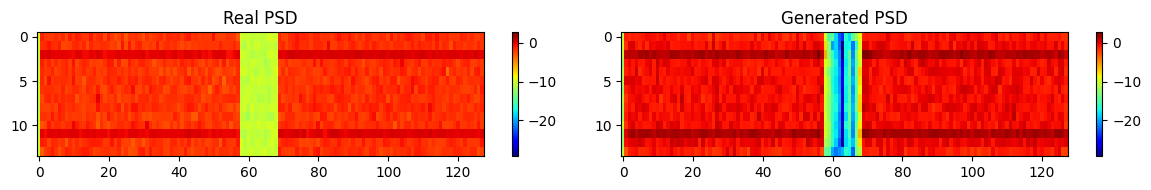

Iteration 30000/30000, Eb/No: 3.1781, Loss_tx: -0.3447, Loss_rx: -0.4357
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.8264e-04 | 5.0731e-03 |       19865 |    41158656 |           50 |        9856 |        31.9 |reached target block errors


In [75]:
offset = 0
grad_check = 1
for i in tqdm(range(offset, num_training_iterations+1)):
    
    train_GAN = True if (i % 10 == 0) else False # Train GAN every 10 iterations (30000/10=3000 times)

    # Sampling a batch of SNRs
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    if train_GAN:
        _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    
        # condition
        condition = h_hat # y_real, h_hat_lmmse, pilots
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
        
        gan_weights_G = WG.get_weights()
        gan_weights_D = WD.get_weights()
    
        # -----------------------------------------------------------------------     
        list_D.append(loss_D.numpy())
        list_G.append(loss_G.numpy())

        if i % 2500 == 0: 
            psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
            psd_generated = compute_psd(y_fake)
            mse= tf.reduce_sum(tf.abs(y_real - y_fake)**2)
    
            print(f"Epoch [{i//10}/{num_training_iterations//10}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, mse: {mse.numpy():.4f}") 
    
        if i % 5000 == 0: 
            # print(np.mean(y_fake), np.mean(y_real))
            # psd_real_line = compute_psd_line(y_real)
            # psd_generated_line = compute_psd_line(y_fake)
            # plot_psd_line(psd_real_line, psd_generated_line)
            
            # plot_phase_amp_distribution(y_real, y_fake)
    
            plot_psd(psd_real, psd_generated)
    
        if i % 5000 == 0: 
            # save GAN weights
            with open(f'gan_weights/testmse_e2e_real_hhat_gan_weights_G_{i}.pkl', 'wb') as f2:
                pickle.dump(gan_weights_G, f2)
            with open(f'gan_weights/testmse_e2e_real_hhat_gan_weights_D_{i}.pkl', 'wb') as f3:
                    pickle.dump(gan_weights_D, f3)

            # np.savez('e2e_receivedY_gan_losses.npz', generator=np.asarray(list_G), discriminator=np.asarray(list_D))

    # -----------------------------------------------------------------------
    gan_weights_G = WG.get_weights()
    model._gan_channel.set_weights(gan_weights_G)
    # -----------------------------------------------------------------------
    
    # ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    loss_tx, y_gen, y_real, grads_tx = E2E_train__tx_step(ebno_db)
    
    # if grad_check == 1:
    #     print("=" * 10 + "Grads_tx" + "=" * 10)
    #     for i, (grad_tx, weight_tx) in enumerate(zip(grads_tx, model.trainable_weights)):
    #         if grad_tx is None:
    #             print(f"❌ None    : {weight_tx.name} - Shape: {weight_tx.shape}")
    #         else:
    #             print(f"✅ Valid   : {weight_tx.name} - Shape: {weight_tx.shape}")

    loss_rx, grads_rx = E2E_train__rx_step(ebno_db)

    # if grad_check == 1:
    #     print("=" * 10 + "Grads_rx" + "=" * 10)
    #     for j, (grad_rx, weight_rx) in enumerate(zip(grads_rx, model.trainable_weights)):
    #         if grad_rx is None:
    #             print(f"❌ None    : {weight_rx.name} - Shape: {weight_rx.shape}")
    #         else:
    #             print(f"✅ Valid   : {weight_rx.name} - Shape: {weight_rx.shape}")
    # grad_check += 1
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 5000 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/testmse_real_hhat_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)
        tf.keras.backend.clear_session()

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/testmse_real_hhat_neural_receiver_weights_trained.pkl', 'wb') as f:
    pickle.dump(weights, f)


### Joint training (baseline)

In [71]:
offset = 0
grad_check = 0
model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=False)
# with open('weights_trained/baseline_model_weights_35000.pkl', 'rb') as f:
#     weights = pickle.load(f)
# model.set_weights(weights)

for i in tqdm(range(offset, num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    weights = model.trainable_weights
    # for w in weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))
     
    if i % 5000 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        ber, bler = sim_ber(eval_model, [10.0], batch_size=16, num_target_block_errors=20, max_mc_iter=100) 

    if i % 5000 == 0:
        with open(f'weights_trained/layernorm_5prb_real_baseline_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/layernorm_5prb_real_baseline_weights_NNmapper.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 1.5244, Loss: 0.6534
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.9944e-01 | 1.0000e+00 |       34521 |       69120 |           32 |          32 |         3.3 |reached target block errors
Iteration 5000/30000, Eb/No: 1.6557, Loss: -0.3554
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 7.9051e-04 | 3.7500e-03 |        2732 |     3456000 |            6 |        1600 |       165.2 |reached max iterations
Iteration 10000/30000, Eb/No: 5.2748, Loss: -0.5249
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block e

### Joint training (Hybrid)

In [118]:
offset = 0
model(batch_size, tf.constant(10.0, tf.float32))
# with open('weights_trained/baseline_model_weights_35000.pkl', 'rb') as f:
#     weights = pickle.load(f)
# model.set_weights(weights)

for i in tqdm(range(offset, num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    weights = model.trainable_weights
    # for w in weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db)
        loss = -rate 
    
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))
     
    if i % 2500 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32))
        eval_model.set_weights(weights)
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/LS_MMSEqualization_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/LS_MMSEqualization_weights_NNdemapper.pkl', 'wb') as f:
    pickle.dump(weights, f)

2026-04-17 11:18:05.171200: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x579a6f032c40


  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 9.9684, Loss: -0.0026
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.9018e-01 | 1.0000e+00 |      262014 |      534528 |          128 |         128 |         0.5 |reached target block errors
Iteration 2500/30000, Eb/No: 7.2272, Loss: -0.5225
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.9473e-03 | 1.7756e-02 |       22899 |    11759616 |           50 |        2816 |         6.6 |reached target block errors
Iteration 5000/30000, Eb/No: 11.3170, Loss: -0.7111
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | b

### Learned Constellation <a class="anchor" id="Constellation"></a>

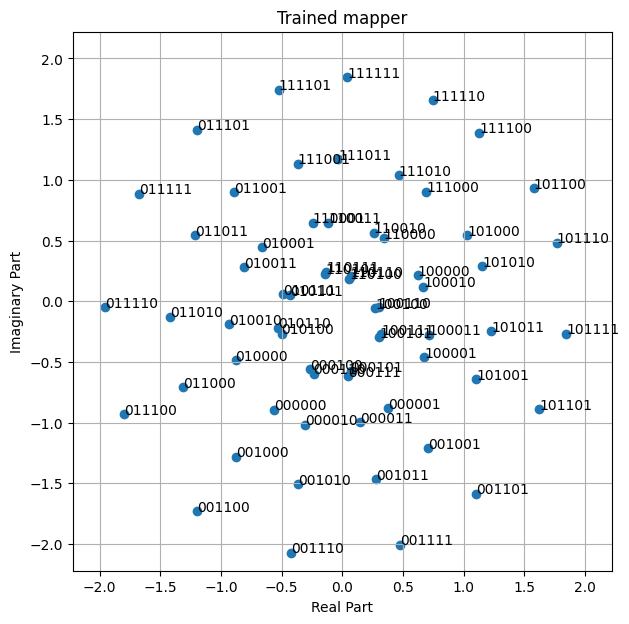

In [80]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem(training=True, use_fec=True)
load_weights(model, "weights_trained/testmse_real_hhat_model_weights_30000.pkl")

constellation_points = tf.complex(model.points_r, model.points_i).numpy()

figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")

for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

plt.show()

In [ ]:
# current_config = {
#     'weight_path': 'weights_trained/pilots_model_weights_50000.pkl',
#     'condition_label': r'$\mathbf{x}_p$ and $\mathbf{y}_p$', 
#     'subplot_index': 0,  # 0, 1, or 2
#     'subplot_label': '(a)'  # '(a)', '(b)', or '(c)'
# }

# current_config = {
#     'weight_path': 'weights_trained/hhat_model_weights_50000.pkl',
#     'condition_label': r'$\hat{\mathbf{h}}$', 
#     'subplot_index': 1,
#     'subplot_label': '(b)'
# }

current_config = {
    'weight_path': 'weights_trained/receivedY_model_weights_50000.pkl',
    'condition_label': r'$\mathbf{Y}_{rg}$', 
    'subplot_index': 2,
    'subplot_label': '(c)'
}

# File to store the figure state
data_state_file = 'constellation_data_state.pkl'

def extract_constellation_data(weight_path):
    """Extract constellation data without plotting"""
    model = E2ESystem(training=True, use_fec=True)
    load_weights(model, weight_path)
    constellation = model.constellation
    return constellation.points

# Load existing data or create new storage
if os.path.exists(data_state_file):
    with open(data_state_file, 'rb') as f:
        plot_data = pickle.load(f)
    print(f"Loaded existing data. Completed: {list(plot_data.keys())}")
else:
    plot_data = {}
    print("Created new data storage")

# Extract and store constellation data for current config
subplot_idx = current_config['subplot_index']
if subplot_idx not in plot_data:
    print(f"Extracting data for subplot {subplot_idx}: {current_config['condition_label']}")
    
    constellation_points = extract_constellation_data(current_config['weight_path'])
    
    plot_data[subplot_idx] = {
        'points': constellation_points,
        'condition_label': current_config['condition_label'],
        'subplot_label': current_config['subplot_label']
    }
    
    # Save the data
    with open(data_state_file, 'wb') as f:
        pickle.dump(plot_data, f)
        
    print(f"Saved data for subplot {subplot_idx}")
else:
    print(f"Data for subplot {subplot_idx} already exists")

print(f"Progress: {len(plot_data)}/3 subplots completed")

# Create and save the complete figure when all data is ready
if len(plot_data) == 3:
    print("All data ready! Creating final plot...")
    
    # Set IEEE paper style
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'font.family': 'serif',
        'font.serif': 'Times New Roman'
    })
    
    # Create fresh figure
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    
    # Plot all subplots
    for i in range(3):
        data = plot_data[i]
        points = data['points']
        condition_label = data['condition_label']
        subplot_label = data['subplot_label']
        
        maxval = np.max(np.abs(points)) * 1.05
        axes[i].set_xlim(-maxval, maxval)
        axes[i].set_ylim(-maxval, maxval)
        axes[i].scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].grid(True, which="both", axis="both", alpha=0.3)
        axes[i].set_title(f"{subplot_label} {condition_label}")
        axes[i].set_xlabel("Real Part")
        axes[i].set_ylabel("Imaginary Part")
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)
    
    # Save EPS
    plt.savefig('learned_constellations.eps', format='eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved learned_constellations.eps successfully!")
    
    # Clean up
    if os.path.exists(data_state_file):
        os.remove(data_state_file)
        print("Cleaned up data file")

else:
    # Show preview of current data
    if plot_data:
        plt.figure(figsize=(3, 3))
        latest_data = plot_data[max(plot_data.keys())]
        points = latest_data['points']
        maxval = np.max(np.abs(points)) * 1.05
        plt.xlim(-maxval, maxval)
        plt.ylim(-maxval, maxval)
        plt.scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        plt.title(f"Preview: {latest_data['condition_label']}")
        plt.grid(True, alpha=0.3)
        plt.show()

## Evaluation (PRB)

In [40]:
prb_configs = {}

for num_prbs in [5, 15, 24]:
    fft_size = num_prbs * 12

    rg = ResourceGrid(
        num_ofdm_symbols=num_ofdm_symbols,
        fft_size=fft_size,
        subcarrier_spacing=subcarrier_spacing,
        num_tx=1,
        num_streams_per_tx=1,
        cyclic_prefix_length=cyclic_prefix_length,
        num_guard_carriers=[0, 0],
        dc_null=False,
        pilot_pattern=pilot_pattern,
        pilot_ofdm_symbol_indices=pilot_ofdm_symbol_indices
    )

    sm = StreamManagement(np.array([[1]]), 1)
    rg_util = ModifiedResourceGridMapper(rg)
    n_t, k_t, num_cbs, k_per_cb, n_per_cb = compute_ldpc_params(
        rg, num_bits_per_symbol, coderate)

    print(f"{num_prbs} PRBs: fft={fft_size}, "
          f"num_data_sym={rg.num_data_symbols}, "
          f"k={k_t}, n={n_t}, "
          f"num_cbs={num_cbs}, k_per_cb={k_per_cb}, n_per_cb={n_per_cb}")

    prb_configs[num_prbs] = {
        'resource_grid': rg,
        'stream_manager': sm,
        'rg_util': rg_util,
        'n_total': n_t,
        'k_total': k_t,
        'num_cbs': num_cbs,
        'k_per_cb': k_per_cb,
        'n_per_cb': n_per_cb,
    }

# ---- Load trained weights from 5-PRB training ----
with open('eval_weights/5prb_real_baseline_weights_NNmapper.pkl', 'rb') as f:
    trained_weights = pickle.load(f)

model(1, tf.constant(10.0, tf.float32))
model.set_weights(trained_weights)

# ---- Build eval models and transfer compatible weights ----
eval_models = {}

for num_prbs, cfg in prb_configs.items():
    eval_m = E2ESystem(
        cfg['resource_grid'],
        cfg['stream_manager'],
        cfg['rg_util'],
        cfg['n_total'],
        cfg['k_total'],
        cfg['num_cbs'],
        cfg['k_per_cb'],
        cfg['n_per_cb'],
        training=False,
        use_fec=True
    )

    # Initialize the eval model
    eval_m(1, tf.constant(10.0, tf.float32))

    # Transfer weights where shapes match
    matched = 0
    skipped = 0
    for tw, ew in zip(model.weights, eval_m.weights):
        if tw.shape == ew.shape:
            ew.assign(tw)
            matched += 1
        else:
            print(f"  SKIP ({num_prbs} PRB): {tw.name} {tw.shape} vs {ew.name} {ew.shape}")
            skipped += 1

    print(f"{num_prbs} PRBs: {matched} weights transferred, {skipped} skipped")
    eval_models[num_prbs] = eval_m

5 PRBs: fft=60, num_data_sym=720, k=2160, n=4320, num_cbs=1, k_per_cb=2160, n_per_cb=4320
15 PRBs: fft=180, num_data_sym=2160, k=6480, n=12960, num_cbs=1, k_per_cb=6480, n_per_cb=12960
24 PRBs: fft=288, num_data_sym=3456, k=10368, n=20736, num_cbs=2, k_per_cb=5184, n_per_cb=10368
5 PRBs: 28 weights transferred, 0 skipped
15 PRBs: 28 weights transferred, 0 skipped
24 PRBs: 28 weights transferred, 0 skipped


In [41]:
for num_prbs in [5, 15, 24]:
    print(f"Evaluating {num_prbs} PRBs (fft={num_prbs*12})")
    print(f"  k={prb_configs[num_prbs]['k_total']}, "
          f"n={prb_configs[num_prbs]['n_total']}, "
          f"num_cbs={prb_configs[num_prbs]['num_cbs']}")
    ber, bler = sim_ber(eval_models[num_prbs], ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
    # Save each PRB config separately
    with open(f'eval_result/{num_prbs}prb_real_baseline_neural_receiver_results.pkl', 'wb') as f:
        pickle.dump({
            'ebno_dbs': ebno_dbs,
            'ber': ber.numpy(),
            'bler': bler.numpy(),
        }, f)

Evaluating 5 PRBs (fft=60)
  k=2160, n=4320, num_cbs=1
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.1773e-01 | 1.0000e+00 |       87845 |      276480 |          128 |         128 |        14.7 |reached target block errors
      0.5 | 3.0691e-01 | 1.0000e+00 |       84854 |      276480 |          128 |         128 |        12.5 |reached target block errors
      1.0 | 2.9699e-01 | 1.0000e+00 |       82111 |      276480 |          128 |         128 |        12.5 |reached target block errors
      1.5 | 2.8520e-01 | 1.0000e+00 |       78853 |      276480 |          128 |         128 |        12.8 |reached target block errors
      2.0 | 2.7405e-01 | 1.0000e+00 |       75770 |      276480 |          128 |         128 |        12.7 |reached target block errors
      2.5 

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [95]:
ebno_dbs_eval = np.arange(-10.0, # Min SNR for evaluation
                     10.0, # Max SNR for evaluation
                     1.0) # Step

In [122]:
# conventional system
conv_model = E2EConvSystem('baseline-perfect-csi', False, True)
ber,bler  = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BER['baseline-perfect-csi'] = ber.numpy()
BLER['baseline-perfect-csi'] = bler.numpy()

conv_model = E2EConvSystem('baseline-ls-estimation', False, True)
ber,bler  = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BER['baseline-ls-estimation'] = ber.numpy()
BLER['baseline-ls-estimation'] = bler.numpy()

with open('eval_result/coderate12_SISO_baseline_e3000', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8429e-01 | 1.0000e+00 |      151962 |      534528 |          128 |         128 |         3.3 |reached target block errors
      0.5 | 2.7337e-01 | 1.0000e+00 |      146123 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.0 | 2.6148e-01 | 1.0000e+00 |      139769 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.5 | 2.5155e-01 | 1.0000e+00 |      134461 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.0 | 2.3926e-01 | 1.0000e+00 |      127891 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.5 | 2.2685e-01 | 1.0000e+00 |      121257 |      534528 |

In [64]:
# with open('eval_result/baseline_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER = BER
# BLER = BLER

with open('eval_weights/real_baseline_weights_NNmapper.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-standard'] = bler.numpy()
BER['neural-receiver-standard'] = ber.numpy()

with open('eval_result/128fft_real_baseline_weights_NNmapper', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.8494e-01 | 1.0000e+00 |      205760 |      534528 |          128 |         128 |        13.9 |reached target block errors
      0.5 | 3.7539e-01 | 1.0000e+00 |      200655 |      534528 |          128 |         128 |        12.5 |reached target block errors
      1.0 | 3.7256e-01 | 1.0000e+00 |      199143 |      534528 |          128 |         128 |        12.5 |reached target block errors
      1.5 | 3.6545e-01 | 1.0000e+00 |      195342 |      534528 |          128 |         128 |        12.5 |reached target block errors
      2.0 | 3.5967e-01 | 1.0000e+00 |      192256 |      534528 |          128 |         128 |        12.9 |reached target block errors
      2.5 | 3.5481e-01 | 1.0000e+00 |      189656 |      534528 |

In [119]:
# with open('eval_result/baseline_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER = BER
# BLER = BLER

with open('eval_weights/LS_MMSEqualization_weights_NNdemapper.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-trained'] = bler.numpy()
BER['neural-receiver-trained'] = ber.numpy()

with open('eval_result/LS_MMSEequalization_model_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 3.3221e-01 | 1.0000e+00 |      177575 |      534528 |          128 |         128 |         0.4 |reached target block errors
      0.5 | 3.2066e-01 | 1.0000e+00 |      171404 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.0 | 3.0897e-01 | 1.0000e+00 |      165154 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.5 | 2.9847e-01 | 1.0000e+00 |      159542 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.0 | 2.8445e-01 | 1.0000e+00 |      152049 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.5 | 2.7148e-01 | 1.0000e+00 |      145115 |      534528 |

In [76]:
with open('eval_weights/testmse_real_hhat_neural_receiver_weights_trained.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-trained'] = bler.numpy()
BER['neural-receiver-trained'] = ber.numpy()

with open('eval_result/testmse_real_hhat_neural_receiver_results', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8259e-01 | 1.0000e+00 |      151050 |      534528 |          128 |         128 |         0.6 |reached target block errors
      0.5 | 2.7347e-01 | 1.0000e+00 |      146176 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.6000e-01 | 1.0000e+00 |      138978 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.4822e-01 | 1.0000e+00 |      132682 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.3890e-01 | 1.0000e+00 |      127700 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.2482e-01 | 1.0000e+00 |      120170 |      534528 |

## Plot

Finally, we plots the BLERs

/tmp/ipykernel_1862282/2851387573.py:87: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((1e-4, 0))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


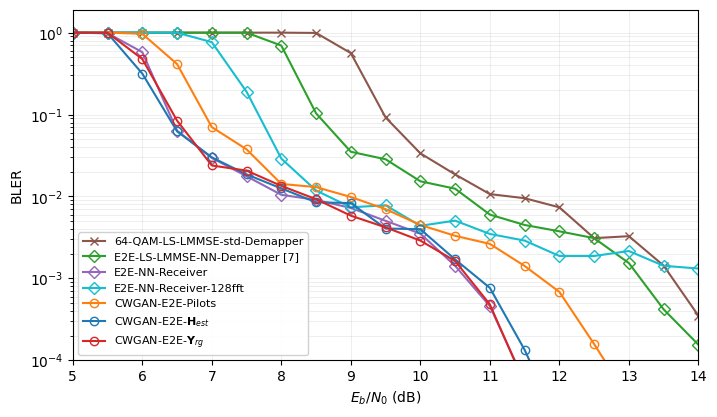

In [ ]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

fig = plt.figure(figsize=(7, 4))

with open('eval_result/coderate12_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_base = BER
BLER_base = BLER
# both QAM+deeprx and NNmapper+deeprx
with open('eval_result/baseline_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st = BER
BLER_st = BLER

with open('eval_result/real_receivedY_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_g = BER
BLER_g = BLER
with open('eval_result/testmse_real_receivedY_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_mg = BER
BLER_mg = BLER

with open('eval_result/real_hhat_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_hh = BER
BLER_hh = BLER
with open('eval_result/testmse_real_hhat_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_mhh = BER
BLER_mhh = BLER

with open('eval_result/real_pilots_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_pp = BER
BLER_pp = BLER
with open('eval_result/testmse_real_pilots_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_mpp = BER
BLER_mpp = BLER
with open('eval_result/real_hinge_pilots_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_hpp = BER
BLER_hpp = BLER

# with open('eval_result/MMSEequalization_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_mmse = BER
# BLER_mmse = BLER
with open('eval_result/LS_MMSEequalization_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_ls_mmse = BER
BLER_ls_mmse = BLER
# with open('eval_result/LS_NNequalization_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_nn_eq = BER
# BLER_nn_eq = BLER

# plt.semilogy(ebno_dbs, BLER_base['baseline-perfect-csi'], 'x-', c=f'C6', label=f'64-QAM-CSI-LMMSE-std-Demapper')
plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x-', c=f'C5', label=f'64-QAM-LS-LMMSE-std-Demapper')
# plt.semilogy(ebno_dbs, BLER_st['neural-receiver-standard'], 'x-', c=f'C9', label=f'64-QAM-NN-Receiver')
# plt.semilogy(ebno_dbs, BLER_mmse['neural-receiver-trained'], 'D-', c=f'C8', markerfacecolor='none', label=f'E2E-NN-Mapper-CSI-LMMSE-NN-Demapper')
plt.semilogy(ebno_dbs, BLER_ls_mmse['neural-receiver-trained'], 'D-', c=f'C2', markerfacecolor='none', label=f'E2E-LS-LMMSE-NN-Demapper [7]')
# plt.semilogy(ebno_dbs, BLER_nn_eq['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-NN-Mapper-LS-NN-Equalizer-Demapper')

plt.semilogy(ebno_dbs, BLER_st['neural-receiver-trained'], 'D-', c=f'C4', markerfacecolor='none', label=f'E2E-NN-Receiver')
plt.semilogy(ebno_dbs, BLER_st2['neural-receiver-trained'], 'D-', c=f'C9', markerfacecolor='none', label=f'E2E-NN-Receiver-128fft')

plt.semilogy(ebno_dbs, BLER_pp['neural-receiver-trained'], 'o-', c=f'C1', markerfacecolor='none', label=r'CWGAN-E2E-Pilots')
# plt.semilogy(ebno_dbs, BLER_mpp['neural-receiver-trained'], 'o-', c=f'C7', markerfacecolor='none', label=r'MSE-CWGAN-E2E-Pilots')
# plt.semilogy(ebno_dbs, BLER_hpp['neural-receiver-trained'], 'o-', c=f'C8', markerfacecolor='none', label=r'Hinge-CWGAN-E2E-Pilots')

plt.semilogy(ebno_dbs, BLER_hh['neural-receiver-trained'], 'o-', c=f'C0', markerfacecolor='none', label=r'CWGAN-E2E-$\mathbf{H}_{est}$')
# plt.semilogy(ebno_dbs, BLER_mhh['neural-receiver-trained'], 'o-', c=f'C6', markerfacecolor='none', label=r'MSE-CWGAN-E2E-$\mathbf{H}_{est}$')
plt.semilogy(ebno_dbs, BLER_g['neural-receiver-trained'], 'o-', c=f'C3', markerfacecolor='none', label=r'CWGAN-E2E-$\mathbf{Y}_{rg}$')
# plt.semilogy(ebno_dbs, BLER_mg['neural-receiver-trained'], 'o-', c=f'C9', markerfacecolor='none', label=r'MSE-CWGAN-E2E-$\mathbf{Y}_{rg}$')

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BLER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
plt.ylim((1e-4, 0))
plt.xlim((5, 14))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)

plt.tight_layout(pad=0.1)
plt.savefig('plots/real_bler.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/real_bler.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


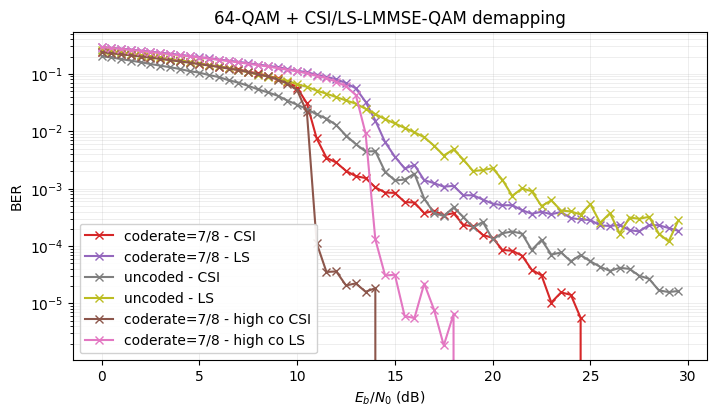

In [54]:
fig = plt.figure(figsize=(7, 4))

with open('eval_result/coderate78_highCo_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_highco78_code = BER
BLER_highco78_code = BLER

# with open('eval_result/coderate12_SISO_baseline_e3000', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_base12_code = BER
# BLER_base12_code = BLER
# with open('eval_result/coderate34_SISO_baseline_e3000', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_base34_code = BER
# BLER_base34_code = BLER
with open('eval_result/coderate78_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_base78_code = BER
BLER_base78_code = BLER
with open('eval_result/uncoded_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs2, BLER, BER = pickle.load(file)
BER_uncoded_code = BER
BLER_uncoded_code = BLER

# plt.semilogy(ebno_dbs, BER_base12_code['baseline-perfect-csi'], 'x-', c=f'C6', label=f'coderate=1/2 - 64-QAM + CSI-LMMSE-QAM demapping')
# plt.semilogy(ebno_dbs, BER_base12_code['baseline-ls-estimation'], 'x-', c=f'C5', label=f'coderate=1/2 - 64-QAM-LS-LMMSE-std-Demapper')
# plt.semilogy(ebno_dbs, BER_base34_code['baseline-perfect-csi'], 'x-', c=f'C1', label=f'coderate=3/4 - 64-QAM + CSI-LMMSE-QAM demapping')
# plt.semilogy(ebno_dbs, BER_base34_code['baseline-ls-estimation'], 'x-', c=f'C2', label=f'coderate=3/4 - 64-QAM-LS-LMMSE-std-Demapper')
plt.semilogy(ebno_dbs, BER_base78_code['baseline-perfect-csi'], 'x-', c=f'C3', label=f'coderate=7/8 - CSI')
plt.semilogy(ebno_dbs, BER_base78_code['baseline-ls-estimation'], 'x-', c=f'C4', label=f'coderate=7/8 - LS')

plt.semilogy(ebno_dbs2, BER_uncoded_code['baseline-perfect-csi'], 'x-', c=f'C7', label=f'uncoded - CSI')
plt.semilogy(ebno_dbs2, BER_uncoded_code['baseline-ls-estimation'], 'x-', c=f'C8', label=f'uncoded - LS')

plt.semilogy(ebno_dbs, BER_highco78_code['baseline-perfect-csi'], 'x-', c=f'C5', label=f'coderate=7/8 - high co CSI')
plt.semilogy(ebno_dbs, BER_highco78_code['baseline-ls-estimation'], 'x-', c=f'C6', label=f'coderate=7/8 - high co LS')

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
# plt.ylim((1e-2, 0))
# plt.xlim((5, 12))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)
plt.title('64-QAM + CSI/LS-LMMSE-QAM demapping')
plt.tight_layout(pad=0.1)
plt.savefig('plots/coderate78_ber.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/coderate78_ber.eps', format='eps', bbox_inches='tight')
plt.show()

/tmp/ipykernel_2528971/3704781269.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((1e-4, 0))


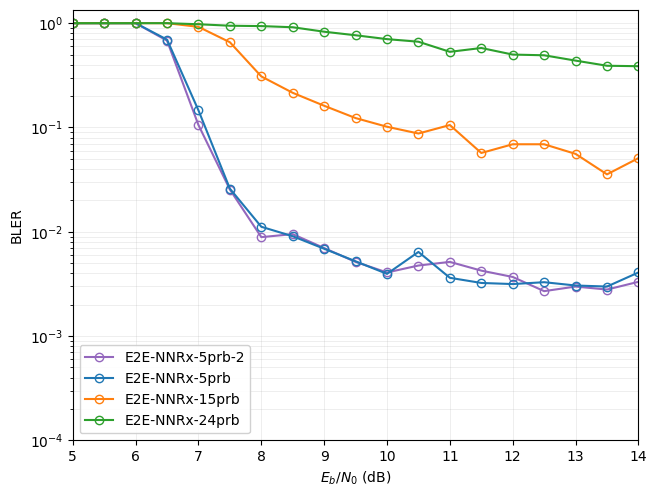

In [ ]:
with open('eval_result/5prb_real_baseline_neural_receiver_results.pkl', 'rb') as file:
    data = pickle.load(file)
ebno_dbs = data['ebno_dbs']
BLER_5prb = data['bler']
BER_5prb = data['ber']
with open('eval_result/15prb_real_baseline_neural_receiver_results.pkl', 'rb') as file:
    data = pickle.load(file)
BLER_15prb = data['bler']
BER_15prb = data['ber']
with open('eval_result/24prb_real_baseline_neural_receiver_results.pkl', 'rb') as file:
    data = pickle.load(file)
BLER_24prb = data['bler']
BER_24prb = data['ber']

plt.semilogy(ebno_dbs, BLER_5prb, 'o-', c='C0', markerfacecolor='none', label=r'E2E-NNRx-5prb')
plt.semilogy(ebno_dbs, BLER_15prb, 'o-', c='C1', markerfacecolor='none', label=r'E2E-NNRx-15prb')
plt.semilogy(ebno_dbs, BLER_24prb, 'o-', c='C2', markerfacecolor='none', label=r'E2E-NNRx-24prb')

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BLER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
plt.ylim((1e-4, 0))
plt.xlim((5, 14))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)

plt.tight_layout(pad=0.1)
plt.show()

## Other

### distribution

In [ ]:
def test_trained_gan_100_realizations(model, WG, WD, epoch_to_load=1000):
    # Load trained weights
    with open(f'gan_weights/e2e_receivedY_gan_weights_G_{epoch_to_load}.pkl', 'rb') as f:
        gan_weights_G = pickle.load(f)
    with open(f'gan_weights/e2e_receivedY_gan_weights_D_{epoch_to_load}.pkl', 'rb') as f:
        gan_weights_D = pickle.load(f)
    
    WG.set_weights(gan_weights_G)
    WD.set_weights(gan_weights_D)
    
    real_freq_responses = []
    fake_freq_responses = []
    real_amplitudes_all = []
    fake_amplitudes_all = []
    real_phases_all = []
    fake_phases_all = []
    
    batch_size = 128
    ebno_db = tf.constant(5.0, tf.float32)  # Fixed SNR
    
    # 100 realizations = 100*14*128 =179200 ofdm symbols
    _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    for i in tqdm(range(100)):
        # _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, y_real) # change the condition
        
        # average each realization over batch and OFDM symbols: [batch,ant,ant,14,128] -> [128]
        real_avg = tf.reduce_mean(y_real, axis=[0, 1, 2, 3]).numpy()  # [128]
        fake_avg = tf.reduce_mean(y_fake, axis=[0, 1, 2, 3]).numpy()  # [128]
        
        # frequency responses
        real_freq_responses.append(real_avg)
        fake_freq_responses.append(fake_avg)
        # amplitudes and phases for PDF analysis
        real_amps = np.abs(y_real.numpy()).flatten()
        fake_amps = np.abs(y_fake.numpy()).flatten()
        real_phases = np.angle(y_real.numpy()).flatten()
        fake_phases = np.angle(y_fake.numpy()).flatten()
        
        real_amplitudes_all.extend(real_amps)
        fake_amplitudes_all.extend(fake_amps)
        real_phases_all.extend(real_phases)
        fake_phases_all.extend(fake_phases)
    
    # compute averages
    real_freq_responses = np.array(real_freq_responses)  # [100, 128]
    fake_freq_responses = np.array(fake_freq_responses)  # [100, 128]
    final_real_avg = np.mean(real_freq_responses, axis=0)  # [128]
    final_fake_avg = np.mean(fake_freq_responses, axis=0)  # [128]
    real_amplitudes_all = np.array(real_amplitudes_all)
    fake_amplitudes_all = np.array(fake_amplitudes_all)
    real_phases_all = np.array(real_phases_all)
    fake_phases_all = np.array(fake_phases_all)
    
    # ===== PLOT 1: average mag/phase =====
    freq_axis = np.linspace(-0.5, 0.5, len(final_real_avg))
    
    plt.figure(figsize=(8, 6))
    
    # magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, 20*np.log10(np.abs(final_real_avg)), 'b-', label='Real Channel', linewidth=1)
    plt.plot(freq_axis, 20*np.log10(np.abs(final_fake_avg)), 'ro--', markerfacecolor='none', label='GAN Channel', linewidth=1)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude [dB]')
    plt.legend()
    plt.grid(True)
    # phase plot
    plt.subplot(2, 1, 2)
    plt.plot(freq_axis, np.angle(final_real_avg), 'b-', label='Real Channel', linewidth=1)
    plt.plot(freq_axis, np.angle(final_fake_avg), 'ro--', markerfacecolor='none', label='GAN Channel', linewidth=1)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Phase [rad]')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    # plt.savefig('averaged_frequency_response_100_realizations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== PLOT 2: channel response amplitude distribution =====
    plt.figure(figsize=(6, 4))
    max_amp = max(np.max(real_amplitudes_all), np.max(fake_amplitudes_all))
    bins = np.linspace(0, max_amp, 80)

    plt.hist(real_amplitudes_all, bins=bins, alpha=0.7, density=True, 
             label='Real Samples', color='blue', histtype='step', linewidth=1)
    plt.hist(fake_amplitudes_all, bins=bins, alpha=0.7, density=True, 
             label='Generated Samples', color='red', histtype='step', linewidth=1, linestyle='--')
    
    plt.xlabel('channel response')
    plt.ylabel('Probability Density Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, max_amp)

    plt.tight_layout()
    # plt.savefig('channel_amplitude_distribution.png', dpi=300, bbox_inches='tight')

    plt.figure(figsize=(6, 4))
    max_phase = max(np.max(real_phases_all), np.max(fake_phases_all))
    bins = np.linspace(0, max_phase, 80)

    plt.hist(real_phases_all, bins=bins, alpha=0.7, density=True, 
             label='Real Samples', color='blue', histtype='step', linewidth=1)
    plt.hist(fake_phases_all, bins=bins, alpha=0.7, density=True, 
             label='Generated Samples', color='red', histtype='step', linewidth=1, linestyle='--')
    
    plt.xlabel('channel response')
    plt.ylabel('Probability Density Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, max_phase)
    
    plt.tight_layout()
    # plt.savefig('channel_phase_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
model = E2ESystem(training=True, use_fec=True)

WG = GANGenerator()
WD = GANDiscriminator()

test_trained_gan_100_realizations(model, WG, WD, 30000)

In [ ]:
# amplitude distribution
real_amplitudes_all = []
fake_amplitudes_all = []
batch_size = 128
ebno_db = tf.constant(10.0, tf.float32)

model = E2ESystem(training=True, use_fec=True)
WG = GANGenerator()
WD = GANDiscriminator()

def load_weights(model, model_weights_path, gan_weights_path):
    with open(f'gan_weights/e2e_{gan_weights_path}_gan_weights_G_30000.pkl', 'rb') as f:
        gan_weights_G = pickle.load(f)
    with open(f'gan_weights/e2e_{gan_weights_path}_gan_weights_D_30000.pkl', 'rb') as f:
        gan_weights_D = pickle.load(f)
    
    WG.set_weights(gan_weights_G)
    WD.set_weights(gan_weights_D)

    model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)

# load_weights(model, "weights_trained/pilots_model_weights_15000.pkl", "pilots")
load_weights(model, "weights_trained/hhat_model_weights_30000.pkl", "hhat")
# load_weights(model, "weights_trained/receivedY_model_weights_30000.pkl", "receivedY")

for i in tqdm(range(100)):  # 100 realizations
    # _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    
    # Get generated samples from GAN
    condition = h_hat
    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
    
    # Collect amplitudes
    real_amps = np.abs(y_real.numpy()).flatten()
    fake_amps = np.abs(y_fake.numpy()).flatten()
    
    real_amplitudes_all.extend(real_amps)
    fake_amplitudes_all.extend(fake_amps)

real_amplitudes_all = np.array(real_amplitudes_all)
fake_amplitudes_all = np.array(fake_amplitudes_all)

np.save("plots/cond_amplitudes_real_model_hhat.npy", real_amplitudes_all)
np.save("plots/cond_amplitudes_fake_model_hhat.npy", fake_amplitudes_all)
print(f"Saved {len(real_amplitudes_all)} real amplitude samples")
print(f"Saved {len(fake_amplitudes_all)} generated amplitude samples")

  0%|          | 0/100 [00:00<?, ?it/s]

Saved 22937600 real amplitude samples
Saved 22937600 generated amplitude samples


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


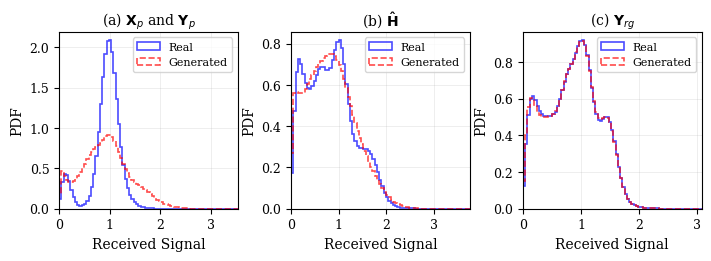

In [139]:
# IEEE formatting parameters
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 11

# Load data
amplitude_files_real = [
    "plots/cond_amplitudes_real_model_pilots.npy",
    "plots/cond_amplitudes_real_model_hhat.npy",
    "plots/cond_amplitudes_real_model_receivedY.npy"
]
amplitude_files_fake = [
    "plots/cond_amplitudes_fake_model_pilots.npy",
    "plots/cond_amplitudes_fake_model_hhat.npy",
    "plots/cond_amplitudes_fake_model_receivedY.npy"
]

titles = ["(a) $\mathbf{X}_p$ and $\mathbf{Y}_p$", "(b) $\mathbf{\hat H}$", "(c) $\mathbf{Y}_{rg}$"]

# IEEE double column width is ~7 inches, single column is ~3.5 inches
# For 3 subplots, use double column width
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))  # IEEE double-column width

for idx, (ax, file_real, file_fake, title) in enumerate(zip(axes, amplitude_files_real, amplitude_files_fake, titles)):
    real_amplitudes = np.load(file_real)
    fake_amplitudes = np.load(file_fake)
    
    max_amp = max(np.max(real_amplitudes), np.max(fake_amplitudes))
    bins = np.linspace(0, max_amp, 80)
    
    ax.hist(real_amplitudes, bins=bins, alpha=0.7, density=True, 
            label='Real', color='blue', histtype='step', linewidth=1.2)
    ax.hist(fake_amplitudes, bins=bins, alpha=0.7, density=True, 
            label='Generated', color='red', histtype='step', linewidth=1.2, linestyle='--')
    
    ax.set_xlabel('Received Signal', fontsize=10)
    ax.set_ylabel('PDF', fontsize=10)
    ax.set_title(title, fontsize=10, pad=5)
    ax.legend(fontsize=8, frameon=True, loc='best')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_xlim(0, max_amp)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout(pad=0.3)
plt.savefig("plots/dist.png", dpi=300, bbox_inches='tight')
plt.savefig('plots/dist.eps', format='eps', bbox_inches='tight')
plt.show()

### Constellation

In [54]:
# constellation plots
model = E2ESystem(training=True, use_fec=True)

def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)

# load_weights(model, "weights_trained/real_pilots_model_weights_30000.pkl")
# load_weights(model, "weights_trained/real_hhat_model_weights_30000.pkl")
load_weights(model, "weights_trained/real_receivedY_model_weights_30000.pkl")

# e2e with deeprx noGAN
# load_weights(model, "weights_trained/baseline_model_weights_30000.pkl")

constellation_points = tf.complex(model.points_r, model.points_i).numpy()
# constellation_points = model.constellation.points.numpy()

np.save("plots/constellation_model_receivedY.npy", constellation_points)
print(f"Saved constellation with {len(constellation_points)} points")

Saved constellation with 64 points


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


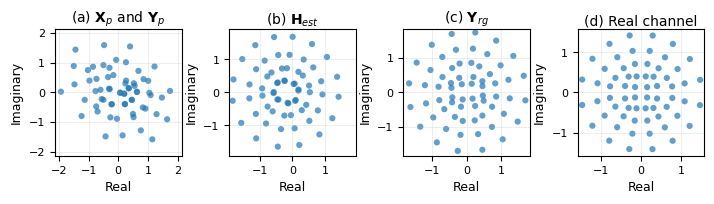

In [55]:
# IEEE formatting parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Load data
constellation_files = [
    "plots/constellation_model_pilots.npy",
    "plots/constellation_model_hhat.npy",
    "plots/constellation_model_receivedY.npy",
    "plots/constellation_model_baseline.npy"
]

titles = ["(a) $\mathbf{X}_p$ and $\mathbf{Y}_p$", "(b) $\mathbf{H}_{est}$", "(c) $\mathbf{Y}_{rg}$", "(d) Real channel"]

# IEEE double-column width with square subplots
fig, axes = plt.subplots(1, 4, figsize=(7, 2.2))

for idx, (ax, file, title) in enumerate(zip(axes, constellation_files, titles)):
    points = np.load(file)
    maxval = np.max(np.abs(points)) * 1.05
    
    ax.set_xlim(-maxval, maxval)
    ax.set_ylim(-maxval, maxval)
    ax.scatter(np.real(points), np.imag(points), s=20, alpha=0.7, edgecolors='none')
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="both", axis="both", linewidth=0.5, alpha=0.3)
    ax.set_title(title, fontsize=10, pad=3)
    ax.set_xlabel("Real", fontsize=9)
    ax.set_ylabel("Imaginary", fontsize=9)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Reduce number of ticks for clarity
    ax.locator_params(axis='both', nbins=5)

plt.tight_layout(pad=0.2)
plt.savefig("plots/learned_constellations.png", dpi=300, bbox_inches='tight')
plt.savefig('plots/learned_constellations.eps', format='eps', bbox_inches='tight')
plt.show()